In [1]:
#  IMPORT LIBRARIES

import os
import sys
import re
import json
import copy
import time
import cv2
from collections import Counter
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from PIL import Image as PILImage
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# XAI Libraries
from captum.attr import LayerGradCam, LayerAttribution, IntegratedGradients
import shap

# Pruning
import torch.nn.utils.prune as prune

# Set device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


print(" ALL LIBRARIES IMPORTED!")
print(f"PyTorch: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Device: {DEVICE}")


 ALL LIBRARIES IMPORTED!
PyTorch: 2.5.1
CUDA Available: False
Device: cpu


In [2]:
# CONFIGURATION

# Dataset paths
BASE_DIR = "KIDO/"
IMAGES_DIR = os.path.join(BASE_DIR, "Images", "Emotion")
TEXTS_DIR = os.path.join(BASE_DIR, "Texts", "Emotion")

TRAIN_CSV = os.path.join(TEXTS_DIR, "Emotion_Train.csv")
TEST_CSV = os.path.join(TEXTS_DIR, "Emotion_Test.csv")

# Model directories
MODEL_DIR = "Emotion_Models/"
XAI_DIR = os.path.join(MODEL_DIR, "xai_results")
COMPRESSED_DIR = os.path.join(MODEL_DIR, "compressed_models")
BENCHMARK_DIR = os.path.join(MODEL_DIR, "benchmark_results")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(XAI_DIR, exist_ok=True)
os.makedirs(COMPRESSED_DIR, exist_ok=True)
os.makedirs(BENCHMARK_DIR, exist_ok=True)

# Training parameters
BATCH_SIZE = 16
MAX_TEXT_LENGTH = 50
EMBEDDING_DIM = 300
EPOCHS = 15
EARLY_STOPPING_PATIENCE = 3
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


print(" CONFIGURATION")
print(f"Images Directory:    {IMAGES_DIR}")
print(f"Texts Directory:     {TEXTS_DIR}")
print(f"Train CSV:           {TRAIN_CSV}")
print(f"Test CSV:            {TEST_CSV}")
print(f"Model Directory:     {MODEL_DIR}")
print(f"Device:              {DEVICE}")


 CONFIGURATION
Images Directory:    KIDO/Images\Emotion
Texts Directory:     KIDO/Texts\Emotion
Train CSV:           KIDO/Texts\Emotion\Emotion_Train.csv
Test CSV:            KIDO/Texts\Emotion\Emotion_Test.csv
Model Directory:     Emotion_Models/
Device:              cpu


In [3]:
#  DATA LOADING 


import re
from sklearn.model_selection import train_test_split

def preprocess_text(text):
    """Clean and preprocess text."""
    text = str(text).lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def load_kido_data():
    """Load KIDO dataset from local structure."""
    data = []
    
    if not os.path.exists(TRAIN_CSV) or not os.path.exists(TEST_CSV):
        print(" CSV files not found!")
        return None, None, None
    
    print(" Loading CSV files...")
    train_df = pd.read_csv(TRAIN_CSV, header=None)
    test_df = pd.read_csv(TEST_CSV, header=None)
    
    print(f"   Train CSV: {len(train_df)} rows")
    print(f"   Test CSV: {len(test_df)} rows")
    
    ID_COL, TEXT_COL, LABEL_COL = 0, 2, 3
    
    print(" Processing data...")
    for split, df in [('train', train_df), ('test', test_df)]:
        success = 0
        for _, row in df.iterrows():
            try:
                img_id = str(row[ID_COL]).strip()
                text = str(row[TEXT_COL]) if pd.notna(row[TEXT_COL]) else ""
                label = str(row[LABEL_COL]).strip() if pd.notna(row[LABEL_COL]) else ""
                
                if label.lower() in ['happiness', 'happy']:
                    label = 'Happiness'
                elif label.lower() in ['sadness', 'sad']:
                    label = 'Sadness'
                else:
                    continue
                
                # Check if image exists with any extension (JPG support)
                img_found = False
                for ext in ['.jpg', '.jpeg', '.png']:
                    img_path = os.path.join(IMAGES_DIR, split, label, f"{img_id}{ext}")
                    if os.path.exists(img_path):
                        img_found = True
                        break
                
                if not img_found:
                    continue
                
                data.append({
                    'image_id': img_id,
                    'text': text,
                    'label': label.lower(),
                    'split': split
                })
                success += 1
            except:
                continue
        print(f"   {split}: {success} samples")
    
    if len(data) == 0:
        print(" No data found!")
        return None, None, None
    
    df = pd.DataFrame(data)
    train_df = df[df['split'] == 'train'].reset_index(drop=True)
    test_df = df[df['split'] == 'test'].reset_index(drop=True)
    
    train_df, val_df = train_test_split(
        train_df, 
        test_size=0.15, 
        random_state=42, 
        stratify=train_df['label']
    )
    
    print(f"\n  Final split:")
    print(f"   Training: {len(train_df)}")
    print(f"   Validation: {len(val_df)}")
    print(f"   Test: {len(test_df)}")
    
    return train_df, val_df, test_df

def build_vocabulary(texts, max_vocab=10000):
    """Build vocabulary from texts."""
    word_counts = Counter()
    for text in texts:
        word_counts.update(preprocess_text(text).split())
    
    vocab = {'<PAD>': 0, '<UNK>': 1}
    for word, _ in word_counts.most_common(max_vocab - 2):
        vocab[word] = len(vocab)
    
    return vocab

def text_to_sequence(text, vocab, max_len):
    """Convert text to token sequence."""
    tokens = preprocess_text(text).split()[:max_len]
    seq = [vocab.get(token, vocab['<UNK>']) for token in tokens]
    seq += [0] * (max_len - len(seq))
    return torch.tensor(seq, dtype=torch.long)

def collate_fn(batch, vocab, max_len):
    """Collate function for DataLoader."""
    images = torch.stack([item['image'] for item in batch])
    labels = torch.stack([item['label'] for item in batch])
    texts = torch.stack([
        text_to_sequence(item['text'], vocab, max_len) for item in batch
    ])
    return {'image': images, 'text': texts, 'label': labels}

class KIDODataset(Dataset):
    """KIDO Dataset - JPG Support."""
    
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_id = row['image_id']
        
        # Try to find image with any extension
        img_path = None
        for split in ['train', 'test']:
            for label in ['Happiness', 'Sadness']:
                for ext in ['.jpg', '.jpeg', '.png']:
                    potential_path = os.path.join(IMAGES_DIR, split, label, f"{img_id}{ext}")
                    if os.path.exists(potential_path):
                        img_path = potential_path
                        break
                if img_path:
                    break
            if img_path:
                break
        
        if img_path:
            try:
                image = PILImage.open(img_path).convert('RGB')
            except:
                image = PILImage.new('RGB', (224, 224), color=(128, 128, 128))
        else:
            image = PILImage.new('RGB', (224, 224), color=(128, 128, 128))
        
        if self.transform:
            image = self.transform(image)
        else:
            transform_default = transforms.Compose([
                transforms.Resize((224, 224)),
                transforms.ToTensor()
            ])
            image = transform_default(image)
        
        label = 0 if row['label'] == 'happiness' else 1
        text = row['text'] if pd.notna(row['text']) else ""
        
        return {
            'image': image,
            'text': text,
            'label': torch.tensor(label, dtype=torch.long)
        }

def create_dataloaders(train_df, val_df, test_df, batch_size=16):
    """Create DataLoaders."""
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    
    train_dataset = KIDODataset(train_df, transform)
    val_dataset = KIDODataset(val_df, transform)
    test_dataset = KIDODataset(test_df, transform)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, val_loader, test_loader

# Load data
print("\n LOADING DATA...")
train_df, val_df, test_df = load_kido_data()

if train_df is None:
    print(" Failed to load data!")
    exit()

# Build vocabulary
print("\n BUILDING VOCABULARY...")
all_texts = train_df['text'].tolist() + val_df['text'].tolist()
vocab = build_vocabulary(all_texts)
vocab_size = len(vocab)
print(f" Vocabulary size: {vocab_size}")

# Create dataloaders
print("\n CREATING DATALOADERS...")
train_loader, val_loader, test_loader = create_dataloaders(
    train_df, val_df, test_df, BATCH_SIZE
)

# Create custom test loader with collate
def make_collate_fn():
    return lambda b: collate_fn(b, vocab, MAX_TEXT_LENGTH)

test_loader_custom = DataLoader(
    test_loader.dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=make_collate_fn()
)

train_loader_custom = DataLoader(
    train_loader.dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=make_collate_fn()
)

print(" Data ready!")


# VERIFY IMAGE LOADING


print("\n VERIFYING IMAGE LOADING...")

sample = test_loader.dataset[0]
print(f"Image shape: {sample['image'].shape}")
print(f"Image range: [{sample['image'].min():.4f}, {sample['image'].max():.4f}]")
print(f"Image std: {sample['image'].std():.4f}")

if sample['image'].std() > 0.05:
    print(" Images loading correctly!")
else:
    print(" Images may be blank")


 LOADING DATA...
 Loading CSV files...
   Train CSV: 9228 rows
   Test CSV: 1632 rows
 Processing data...
   train: 9228 samples
   test: 1632 samples

  Final split:
   Training: 7843
   Validation: 1385
   Test: 1632

 BUILDING VOCABULARY...
 Vocabulary size: 3423

 CREATING DATALOADERS...
 Data ready!

 VERIFYING IMAGE LOADING...
Image shape: torch.Size([3, 224, 224])
Image range: [0.0157, 1.0000]
Image std: 0.1040
 Images loading correctly!


In [4]:
#  MODEL COMPONENTS

class BiLSTMTextEncoder(nn.Module):
    """Bi-LSTM Text Encoder with Attention."""
    def __init__(self, vocab_size, embed_dim=300, hidden=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden, 2, bidirectional=True, 
                           batch_first=True, dropout=dropout)
        self.attention = nn.Linear(hidden * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.output_dim = hidden * 2
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, _ = self.lstm(embedded)
        attn_weights = torch.softmax(self.attention(lstm_out), dim=1)
        context = torch.sum(attn_weights * lstm_out, dim=1)
        return context

class GRUTextEncoder(nn.Module):
    """GRU Text Encoder with Attention."""
    def __init__(self, vocab_size, embed_dim=300, hidden=128, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.gru = nn.GRU(embed_dim, hidden, 2, bidirectional=True, 
                         batch_first=True, dropout=dropout)
        self.attention = nn.Linear(hidden * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.output_dim = hidden * 2
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        gru_out, _ = self.gru(embedded)
        attn_weights = torch.softmax(self.attention(gru_out), dim=1)
        context = torch.sum(attn_weights * gru_out, dim=1)
        return context

def get_vision_encoder(name, pretrained=False):
    """Get vision backbone with feature dimension."""
    backbones = {
        'mobilenet_v2': (models.mobilenet_v2, 1280),
        'efficientnet_b0': (models.efficientnet_b0, 1280),
        'shufflenet_v2_x1_0': (models.shufflenet_v2_x1_0, 1024),
        'squeezenet1_1': (models.squeezenet1_1, 512),
    }
    
    if name not in backbones:
        available = list(backbones.keys())
        raise ValueError(f"Unknown model: {name}. Available: {available}")
    
    model_fn, dim = backbones[name]
    model = model_fn(pretrained=pretrained)
    
    if hasattr(model, 'classifier'):
        model.classifier = nn.Identity()
    elif hasattr(model, 'fc'):
        model.fc = nn.Identity()
    
    return model, dim

class MultimodalModel(nn.Module):
    """Multimodal emotion classifier."""
    def __init__(self, vision_name, text_encoder, dropout=0.5):
        super().__init__()
        
        self.vision, vdim = get_vision_encoder(vision_name)
        
        self.vision_proj = nn.Sequential(
            nn.Linear(vdim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        self.text_encoder = text_encoder
        
        self.text_proj = nn.Sequential(
            nn.Linear(text_encoder.output_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        fusion_dim = 512 + 256
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 2)
        )
        
    def forward(self, images, texts):
        v = self.vision(images)
        if v.dim() > 2:
            v = v.view(v.size(0), -1)
        v = self.vision_proj(v)
        
        t = self.text_encoder(texts)
        t = self.text_proj(t)
        
        fused = torch.cat([v, t], dim=1)
        return self.classifier(fused)
    
    def get_parameters(self):
        return self.parameters()

def create_model_from_config(config, vocab_size):
    """Create model from configuration."""
    if config['text_encoder'] == 'bilstm':
        text_enc = BiLSTMTextEncoder(vocab_size, hidden=config.get('text_hidden', 128))
    elif config['text_encoder'] == 'gru':
        text_enc = GRUTextEncoder(vocab_size, hidden=config.get('text_hidden', 128))
    else:
        raise ValueError(f"Unknown text encoder: {config['text_encoder']}")
    
    return MultimodalModel(config['vision'], text_enc)

def get_model_size(model):
    """Get model size in MB."""
    param_size = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_size = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_size + buffer_size) / 1024 / 1024

def get_model_params(model):
    return sum(p.numel() for p in model.parameters())

def evaluate_model(model, test_loader, device):
    """Evaluate model accuracy."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating"):
            images = batch['image'].to(device)
            texts = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, texts)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

print(" Model components ready!")

 Model components ready!


In [5]:
# LOAD TRAINED MODELS

SUCCESSFUL_MODELS = [
    'MM_MobileNetV2_BiLSTM',
    'MM_EfficientNet_B0_BiLSTM',
    'MM_MobileNetV2_GRU',
    'MM_ShuffleNetV2_BiLSTM',
    'MM_ShuffleNetV2_GRU',
]

MODEL_CONFIGS = {
    'MM_MobileNetV2_BiLSTM': {'vision': 'mobilenet_v2', 'text_encoder': 'bilstm', 'text_hidden': 128},
    'MM_EfficientNet_B0_BiLSTM': {'vision': 'efficientnet_b0', 'text_encoder': 'bilstm', 'text_hidden': 128},
    'MM_MobileNetV2_GRU': {'vision': 'mobilenet_v2', 'text_encoder': 'gru', 'text_hidden': 128},
    'MM_ShuffleNetV2_BiLSTM': {'vision': 'shufflenet_v2_x1_0', 'text_encoder': 'bilstm', 'text_hidden': 128},
    'MM_ShuffleNetV2_GRU': {'vision': 'shufflenet_v2_x1_0', 'text_encoder': 'gru', 'text_hidden': 128},
}

def load_trained_model(model_name, model_dir, vocab_size, device):
    model_path = os.path.join(model_dir, f"{model_name}_final.pt")
    
    if not os.path.exists(model_path):
        print(f" Model not found: {model_path}")
        return None, None
    
    try:
        config = MODEL_CONFIGS[model_name]
        model = create_model_from_config(config, vocab_size)
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'], strict=False)
        model.to(device)
        model.eval()
        
        print(f" Loaded {model_name}")
        print(f"   Best Accuracy: {checkpoint['best_accuracy']:.4f}")
        
        return model, checkpoint
        
    except Exception as e:
        print(f" Error loading {model_name}: {e}")
        return None, None


print(" LOADING TRAINED MODELS")

loaded_models = {}

for model_name in SUCCESSFUL_MODELS:
    model_path = os.path.join(MODEL_DIR, f"{model_name}_final.pt")
    if os.path.exists(model_path):
        model, checkpoint = load_trained_model(model_name, MODEL_DIR, vocab_size, DEVICE)
        if model is not None:
            loaded_models[model_name] = {
                'model': model,
                'checkpoint': checkpoint,
                'config': MODEL_CONFIGS[model_name]
            }
    else:
        print(f"  {model_name} not found")


print(f" Loaded {len(loaded_models)} models")

 LOADING TRAINED MODELS
 Loaded MM_MobileNetV2_BiLSTM
   Best Accuracy: 0.9632
 Loaded MM_EfficientNet_B0_BiLSTM
   Best Accuracy: 0.9588
 Loaded MM_MobileNetV2_GRU
   Best Accuracy: 0.9617
 Loaded MM_ShuffleNetV2_BiLSTM
   Best Accuracy: 0.9545
 Loaded MM_ShuffleNetV2_GRU
   Best Accuracy: 0.9617
 Loaded 5 models


In [6]:
#  GRAD-CAM IMPLEMENTATION

class GradCAMExplainer:
    """Grad-CAM explainer for vision branch."""
    
    def __init__(self, model, device):
        self.model = model
        self.device = device
        self.model.eval()
    
    def get_target_layer(self, model):
        """Find the last convolutional layer."""
        vision = model.vision
        
        if hasattr(vision, 'features'):
            if hasattr(vision.features, '_modules'):
                keys = list(vision.features._modules.keys())
                if keys:
                    return vision.features._modules[keys[-1]]
        elif hasattr(vision, 'layers'):
            return vision.layers[-1]
        elif hasattr(vision, 'conv5'):
            return vision.conv5
        elif hasattr(vision, 'model'):
            return self.get_target_layer(vision.model)
        
        for module in vision.modules():
            if isinstance(module, nn.Conv2d):
                return module
        return vision
    
    def generate_heatmap(self, image, target_class=0):
        """Generate Grad-CAM heatmap."""
        self.model.eval()
        target_layer = self.get_target_layer(self.model)
        
        if target_layer is None:
            target_layer = self.model.vision
        
        try:
            grad_cam = LayerGradCam(self.model, target_layer)
            
            if image.dim() == 5:
                input_image = image.squeeze(1).to(self.device)
            elif image.dim() == 4:
                input_image = image.to(self.device)
            else:
                input_image = image.unsqueeze(0).to(self.device)
            
            if input_image.dim() == 5:
                input_image = input_image.squeeze(1)
            
            dummy_text = torch.zeros(input_image.size(0), 50, dtype=torch.long).to(self.device)
            
            attributions = grad_cam.attribute(
                input_image,
                target=target_class,
                additional_forward_args=(dummy_text,)
            )
            
            heatmap = LayerAttribution.interpolate(attributions, (224, 224))
            heatmap = heatmap.squeeze().cpu().detach().numpy()
            heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)
            
            return heatmap
            
        except Exception as e:
            print(f"    Grad-CAM error: {e}")
            return np.random.rand(224, 224)
    
    def visualize(self, image, target_class=0, save_path=None):
        """Visualize Grad-CAM with matplotlib."""
        heatmap = self.generate_heatmap(image, target_class)
        
        # Convert image to display
        if isinstance(image, torch.Tensor):
            img = image.cpu().detach().numpy()
            if img.ndim == 4:
                img = img.squeeze(0)
            if img.shape[0] == 3:
                img = img.transpose(1, 2, 0)
            img = np.clip(img, 0, 1)
        
        # Resize heatmap
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        
        # Create overlay
        heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
        heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
        img_uint8 = np.uint8(255 * img)
        overlay = cv2.addWeighted(img_uint8, 0.6, heatmap_color, 0.4, 0)
        
        # Display with matplotlib
        label = "Happy" if target_class == 0 else "Sad"
        
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        axes[0].imshow(img)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        axes[1].imshow(heatmap, cmap='jet')
        axes[1].set_title('Grad-CAM Heatmap')
        axes[1].axis('off')
        
        axes[2].imshow(overlay)
        axes[2].set_title(f'Overlay - Target: {label}')
        axes[2].axis('off')
        
        plt.suptitle(f'Grad-CAM Explanation - {label}')
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"    Saved to: {save_path}")
        
        plt.show()
        return heatmap

print(" Grad-CAM ready!")

 Grad-CAM ready!


In [7]:
#  ATTENTION VISUALIZATION

class AttentionVisualizer:
    """Visualize attention weights from text encoder."""
    
    def __init__(self, model, vocab, max_len=50):
        self.model = model
        self.vocab = vocab
        self.max_len = max_len
        self.model.eval()
    
    def get_attention_weights(self, text):
        """Extract attention weights from text encoder."""
        if isinstance(text, str):
            text_seq = text_to_sequence(text, self.vocab, self.max_len)
        elif isinstance(text, torch.Tensor):
            text_seq = text
        else:
            raise ValueError("Text must be string or tensor")
        
        if text_seq.dim() == 1:
            text_seq = text_seq.unsqueeze(0)
        
        text_encoder = self.model.text_encoder
        
        with torch.no_grad():
            embedded = text_encoder.embedding(text_seq)
            
            if hasattr(text_encoder, 'lstm'):
                encoder_out, _ = text_encoder.lstm(embedded)
            elif hasattr(text_encoder, 'gru'):
                encoder_out, _ = text_encoder.gru(embedded)
            else:
                raise ValueError("Text encoder must have 'lstm' or 'gru'")
            
            attn_scores = text_encoder.attention(encoder_out)
            attn_weights = torch.softmax(attn_scores, dim=1)
        
        return attn_weights.squeeze().cpu().numpy()
    
    def visualize(self, text, save_path=None):
        """Visualize attention weights as heatmap."""
        weights = self.get_attention_weights(text)
        
        if isinstance(text, str):
            tokens = preprocess_text(text).split()[:len(weights)]
        else:
            tokens = [f"tok_{i}" for i in range(len(weights))]
        
        fig, ax = plt.subplots(figsize=(14, 4))
        weights_reshaped = weights.reshape(1, -1)
        
        sns.heatmap(weights_reshaped, 
                    xticklabels=tokens,
                    cmap='YlOrRd',
                    cbar=True,
                    ax=ax,
                    annot=False)
        ax.set_title('Attention Weights')
        ax.set_xlabel('Tokens')
        ax.set_ylabel('Attention Score')
        
        plt.tight_layout()
        
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight')
            print(f"    Saved to: {save_path}")
        
        plt.show()
        return fig
    
    def get_top_words(self, text, top_k=10):
        """Get top-k words with highest attention weights."""
        weights = self.get_attention_weights(text)
        
        if isinstance(text, str):
            tokens = preprocess_text(text).split()[:len(weights)]
        else:
            tokens = [f"tok_{i}" for i in range(len(weights))]
        
        top_indices = np.argsort(weights)[-top_k:][::-1]
        top_words = [(tokens[i], weights[i]) for i in top_indices if i < len(tokens)]
        
        return top_words

print(" Attention visualization ready!")

 Attention visualization ready!


 RUNNING XAI ON ALL MODELS
 XAI for: MM_MobileNetV2_BiLSTM

 Grad-CAM Explanation:
   Generating for Happy...
    Saved to: Emotion_Models/xai_results\MM_MobileNetV2_BiLSTM\gradcam_Happy.png


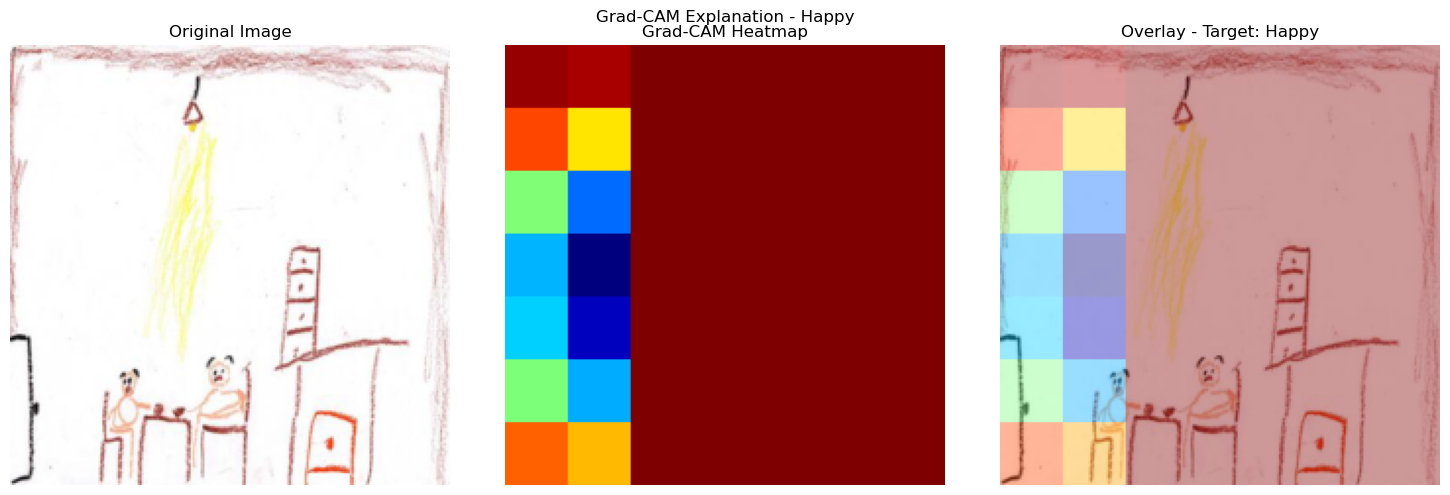

   Generating for Sad...
    Saved to: Emotion_Models/xai_results\MM_MobileNetV2_BiLSTM\gradcam_Sad.png


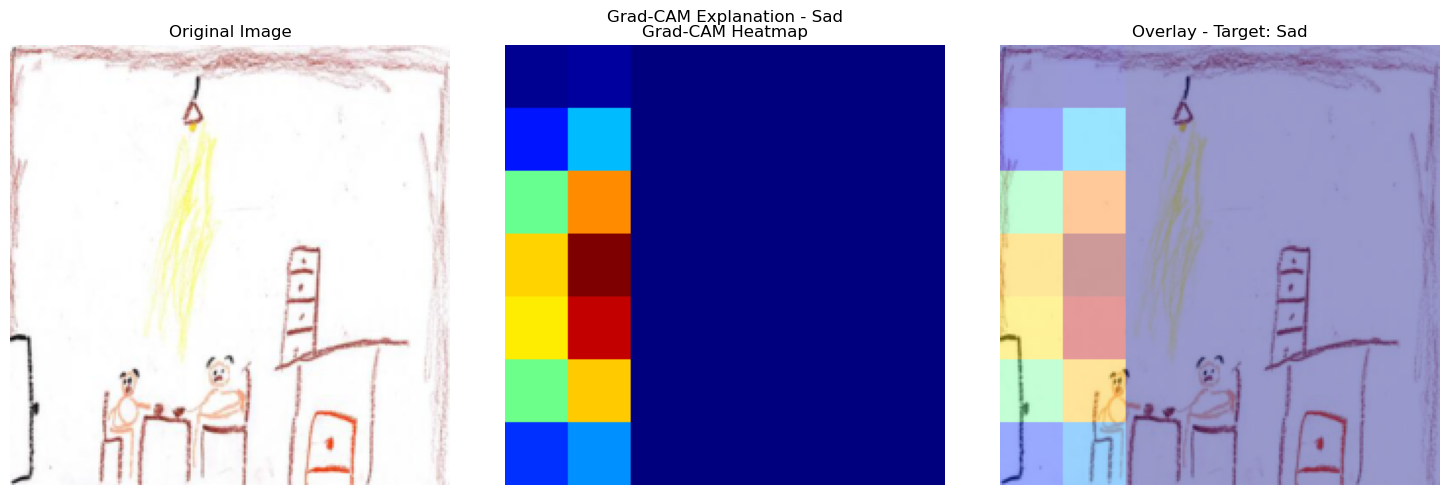

    Grad-CAM completed for both classes!

 Attention Visualization:
   Top attention words:
      'tok_49': 0.1356
      'tok_48': 0.0797
      'tok_47': 0.0521
      'tok_46': 0.0385
      'tok_45': 0.0314
    Saved to: Emotion_Models/xai_results\MM_MobileNetV2_BiLSTM\attention.png


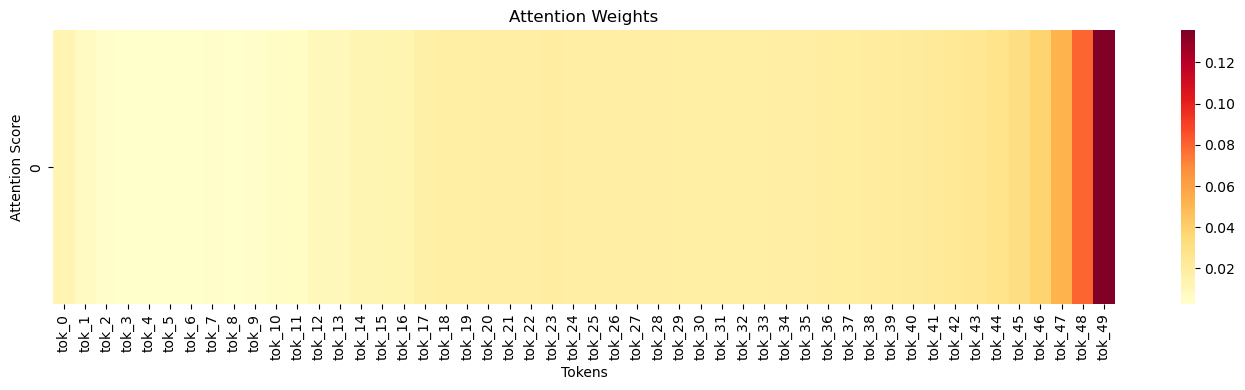

    Attention visualization completed!
 XAI for: MM_EfficientNet_B0_BiLSTM

 Grad-CAM Explanation:
   Generating for Happy...
    Saved to: Emotion_Models/xai_results\MM_EfficientNet_B0_BiLSTM\gradcam_Happy.png


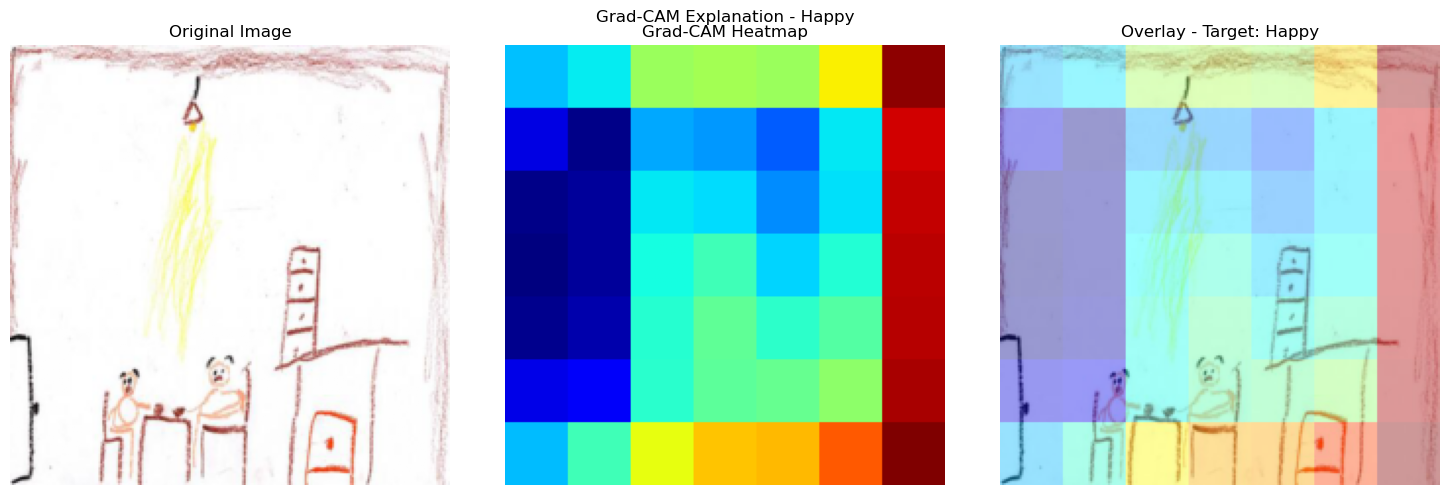

   Generating for Sad...
    Saved to: Emotion_Models/xai_results\MM_EfficientNet_B0_BiLSTM\gradcam_Sad.png


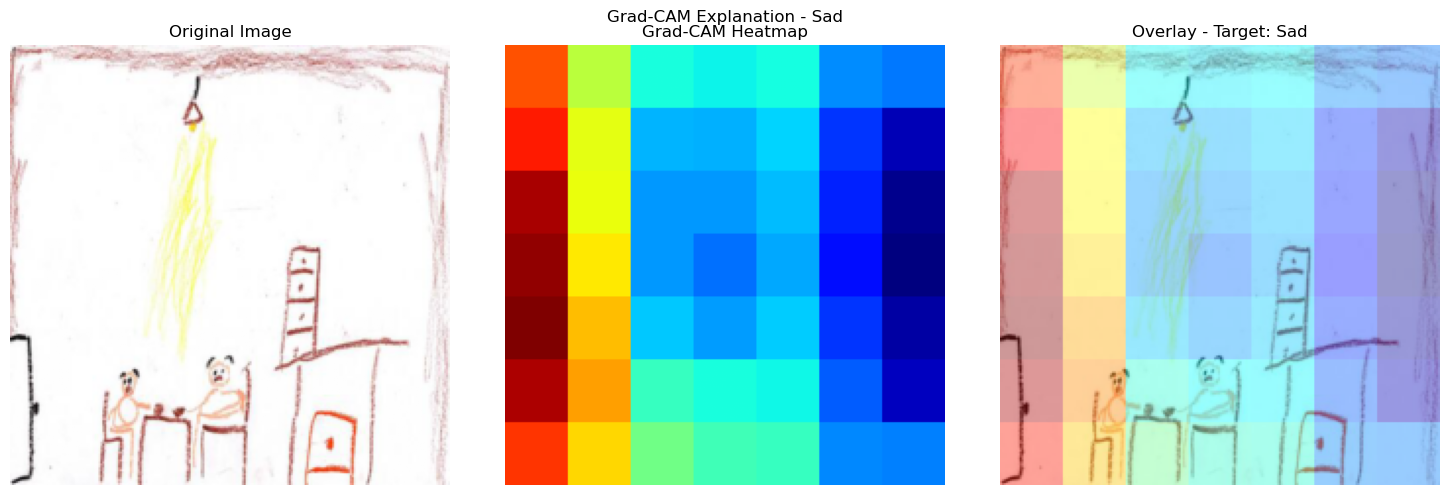

    Grad-CAM completed for both classes!

 Attention Visualization:
   Top attention words:
      'tok_7': 0.1157
      'tok_8': 0.1119
      'tok_9': 0.0961
      'tok_1': 0.0921
      'tok_6': 0.0890
    Saved to: Emotion_Models/xai_results\MM_EfficientNet_B0_BiLSTM\attention.png


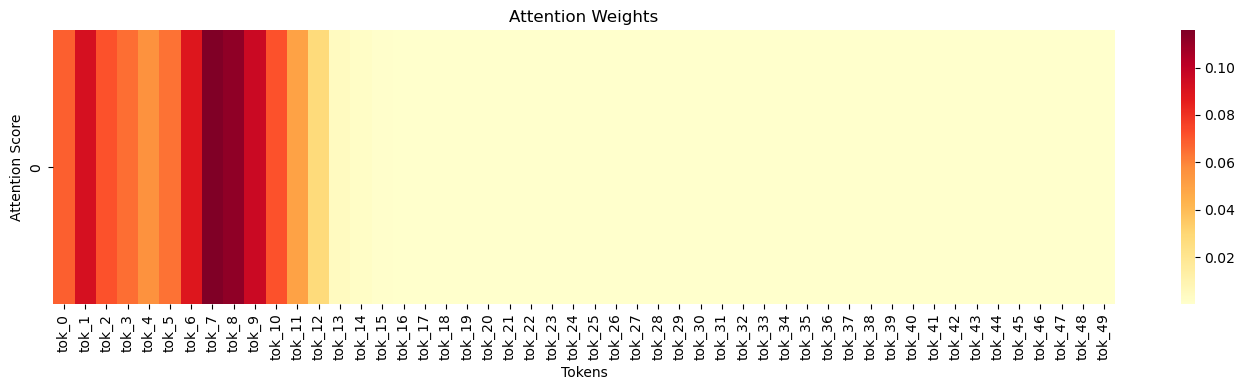

    Attention visualization completed!
 XAI for: MM_MobileNetV2_GRU

 Grad-CAM Explanation:
   Generating for Happy...
    Saved to: Emotion_Models/xai_results\MM_MobileNetV2_GRU\gradcam_Happy.png


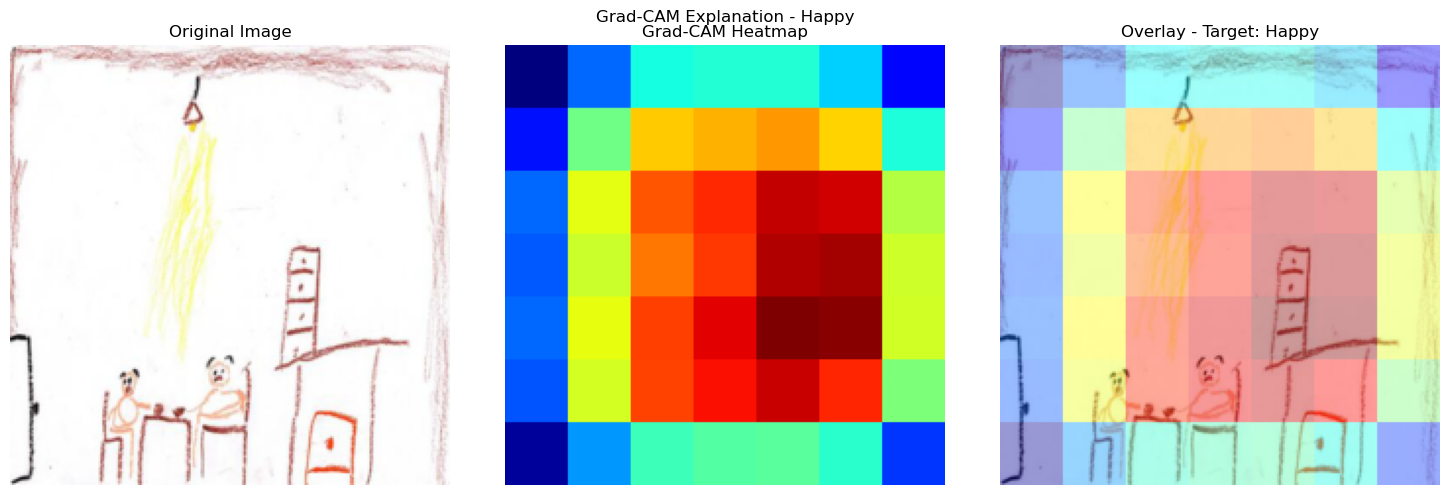

   Generating for Sad...
    Saved to: Emotion_Models/xai_results\MM_MobileNetV2_GRU\gradcam_Sad.png


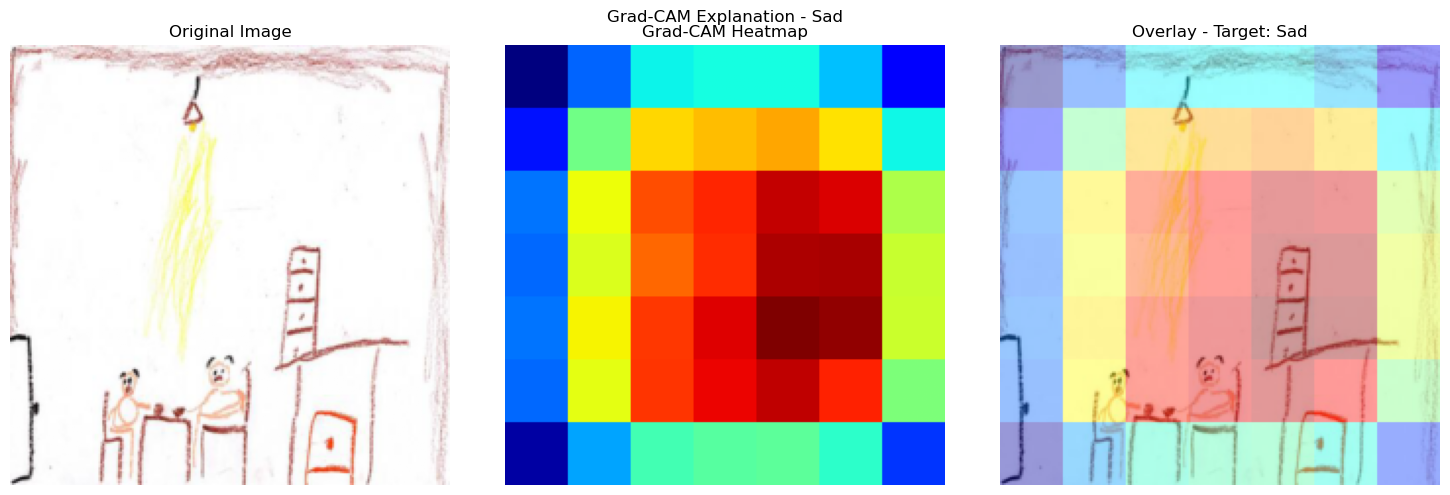

    Grad-CAM completed for both classes!

 Attention Visualization:
   Top attention words:
      'tok_13': 0.1153
      'tok_12': 0.1095
      'tok_14': 0.0887
      'tok_9': 0.0773
      'tok_15': 0.0698
    Saved to: Emotion_Models/xai_results\MM_MobileNetV2_GRU\attention.png


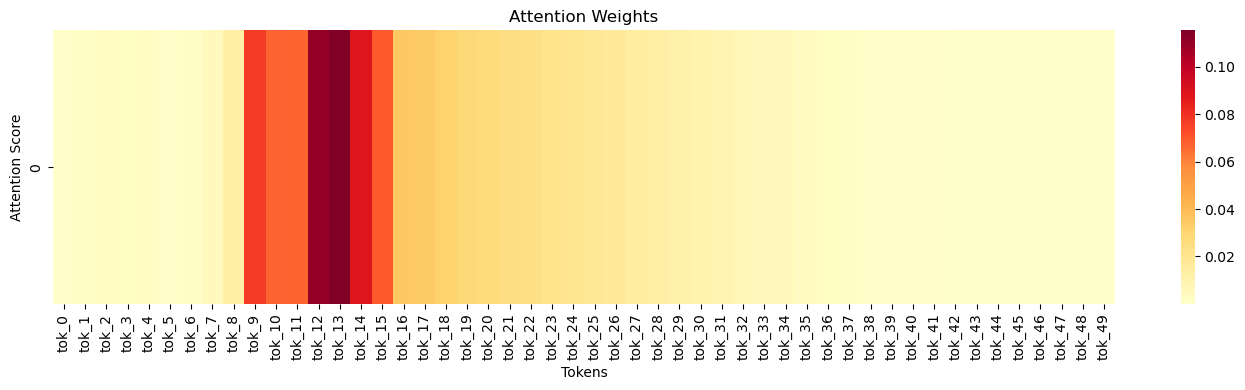

    Attention visualization completed!
 XAI for: MM_ShuffleNetV2_BiLSTM

 Grad-CAM Explanation:
   Generating for Happy...
    Saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_BiLSTM\gradcam_Happy.png


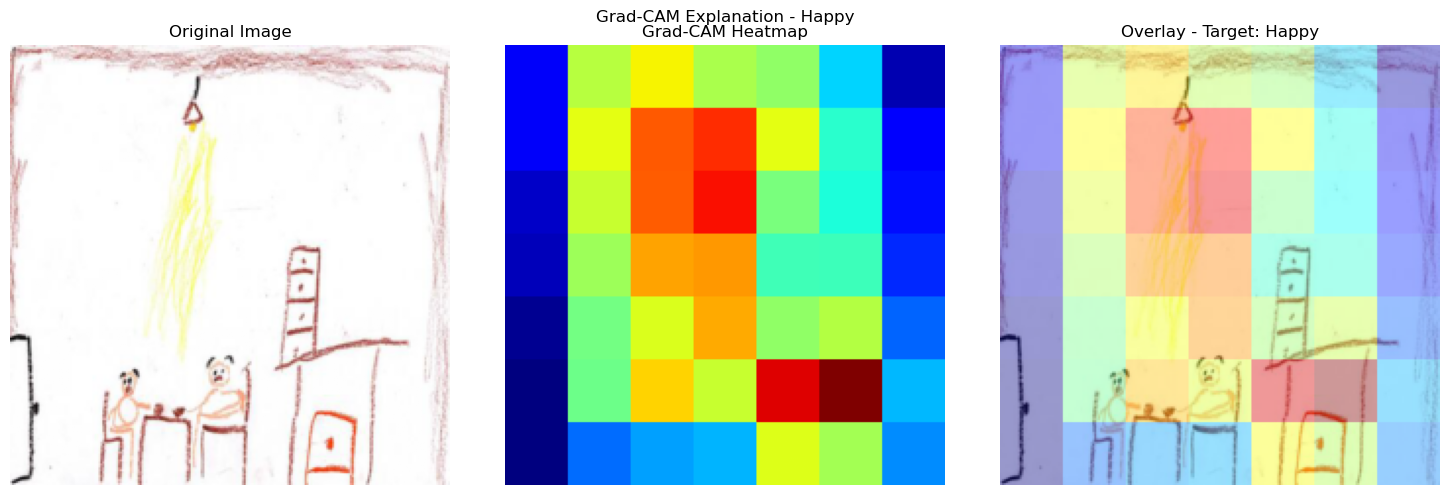

   Generating for Sad...
    Saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_BiLSTM\gradcam_Sad.png


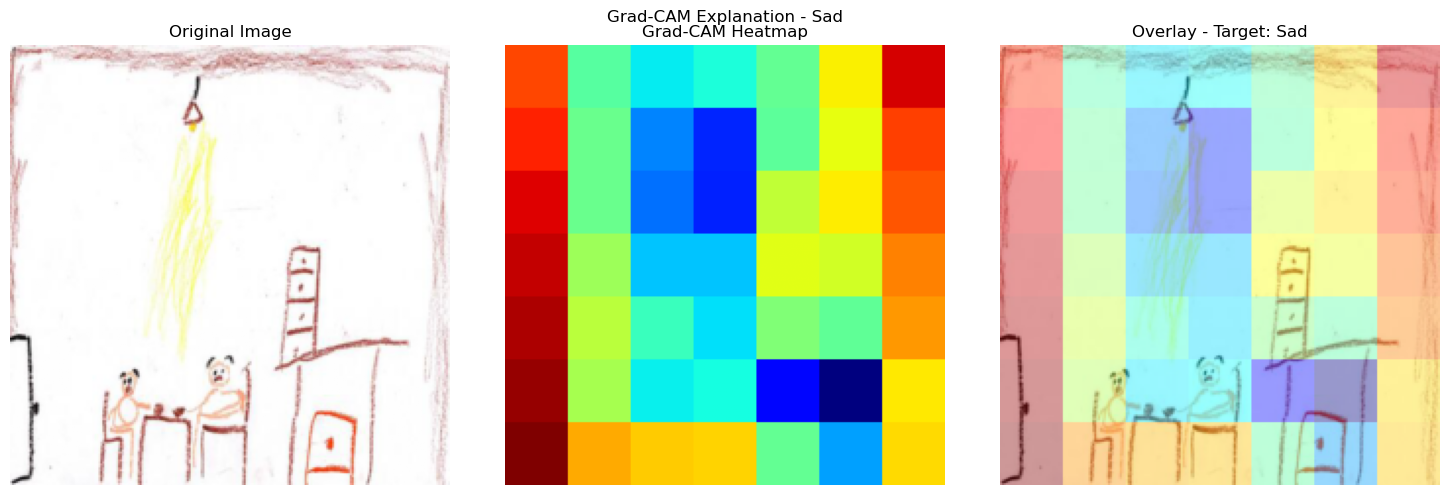

    Grad-CAM completed for both classes!

 Attention Visualization:
   Top attention words:
      'tok_8': 0.2590
      'tok_9': 0.1843
      'tok_7': 0.1451
      'tok_10': 0.0868
      'tok_11': 0.0728
    Saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_BiLSTM\attention.png


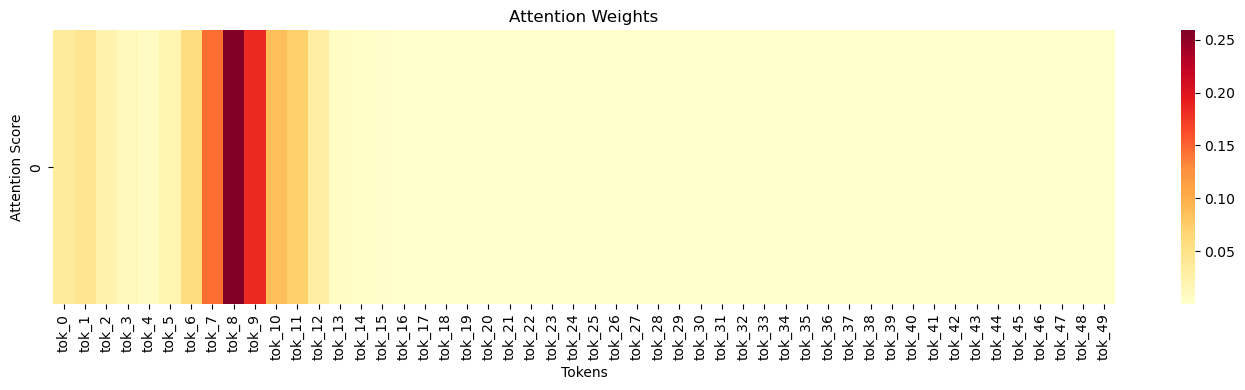

    Attention visualization completed!
 XAI for: MM_ShuffleNetV2_GRU

 Grad-CAM Explanation:
   Generating for Happy...
    Saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_GRU\gradcam_Happy.png


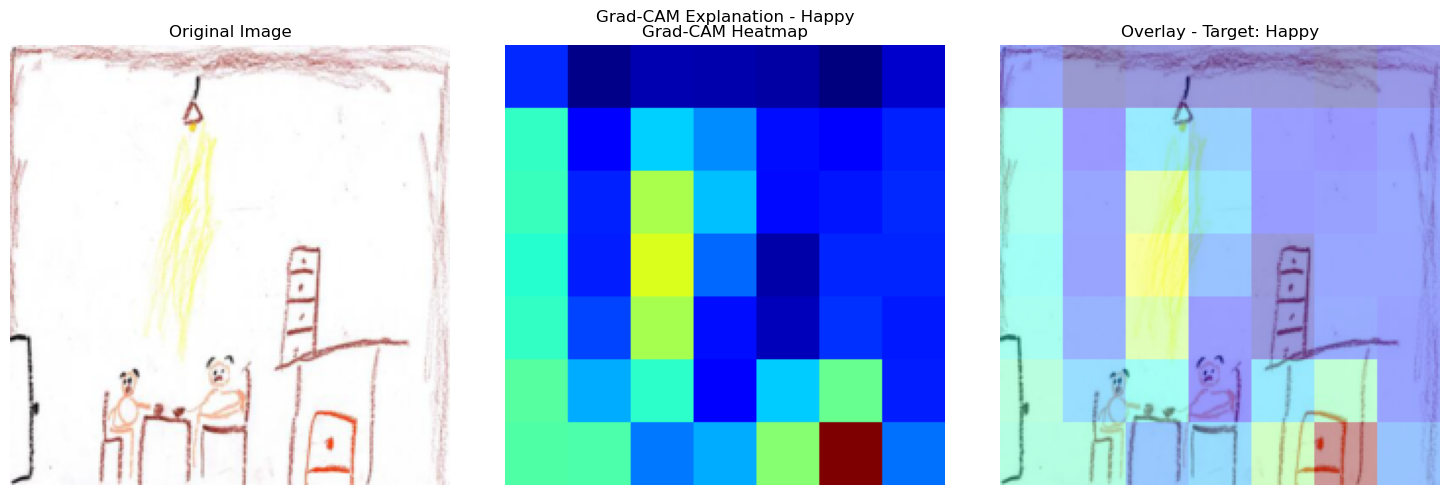

   Generating for Sad...
    Saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_GRU\gradcam_Sad.png


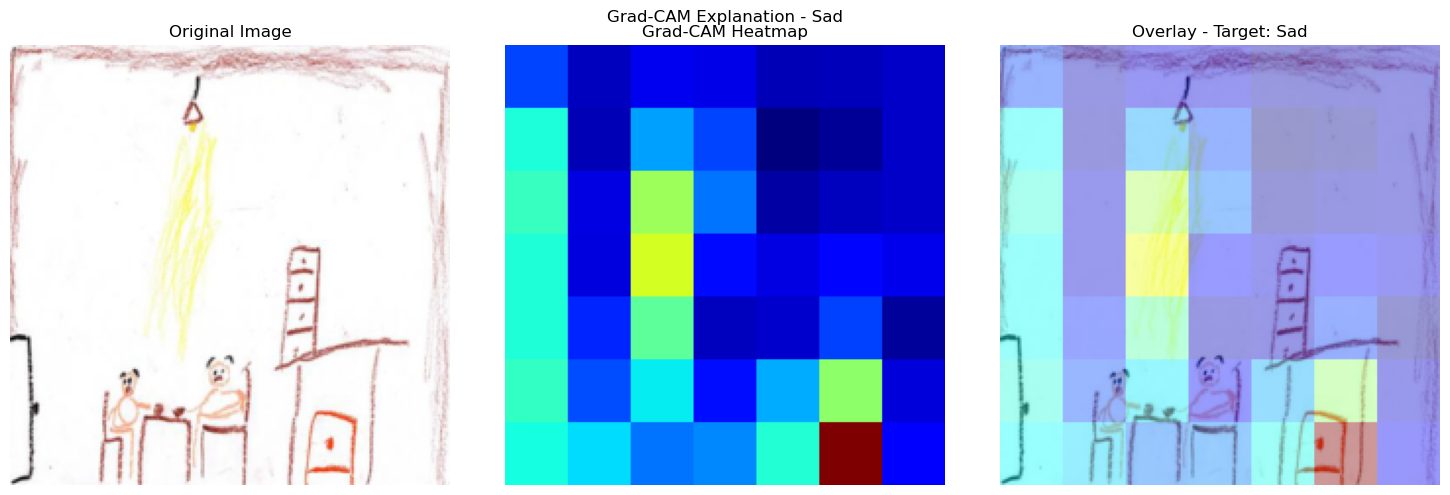

    Grad-CAM completed for both classes!

 Attention Visualization:
   Top attention words:
      'tok_9': 0.2338
      'tok_10': 0.1507
      'tok_12': 0.1005
      'tok_8': 0.0860
      'tok_11': 0.0767
    Saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_GRU\attention.png


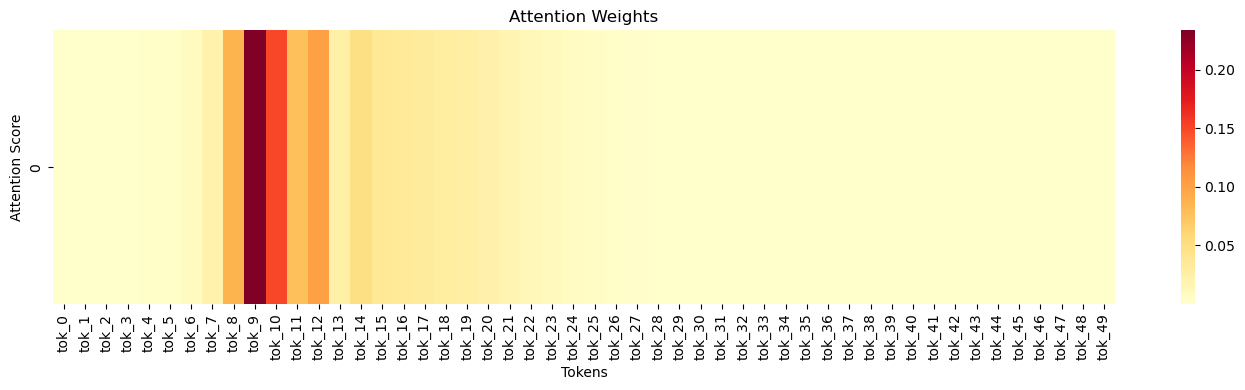

    Attention visualization completed!
 XAI COMPLETE!

 XAI Summary:
                    Model  Accuracy    GradCAM  Attention
    MM_MobileNetV2_BiLSTM  0.963177  Completed  Completed
MM_EfficientNet_B0_BiLSTM  0.958845  Completed  Completed
       MM_MobileNetV2_GRU  0.961733  Completed  Completed
   MM_ShuffleNetV2_BiLSTM  0.954513  Completed  Completed
      MM_ShuffleNetV2_GRU  0.961733  Completed  Completed


In [8]:
# RUN XAI ON ALL MODELS



print(" RUNNING XAI ON ALL MODELS")


# Get sample data
sample_batch = None
for batch in test_loader_custom:
    sample_batch = batch
    break

if sample_batch is None:
    print(" No sample data found!")
    sample_batch = {'image': torch.randn(1, 3, 224, 224), 'text': torch.randint(0, 100, (1, 50))}

xai_results = {}

for model_name, data in loaded_models.items():
    print(f" XAI for: {model_name}")

    
    model = data['model']
    checkpoint = data['checkpoint']
    
    model_xai_dir = os.path.join(XAI_DIR, model_name)
    os.makedirs(model_xai_dir, exist_ok=True)
    
    xai_results[model_name] = {
        'accuracy': checkpoint['best_accuracy'],
        'gradcam': 'Failed',
        'attention': 'Failed'
    }
    
    # 1. Grad-CAM
    print("\n Grad-CAM Explanation:")
    try:
        grad_cam = GradCAMExplainer(model, DEVICE)
        sample_image = sample_batch['image'][0:1]
        
        for target_class, label in enumerate(['Happy', 'Sad']):
            print(f"   Generating for {label}...")
            save_path = os.path.join(model_xai_dir, f'gradcam_{label}.png')
            grad_cam.visualize(sample_image, target_class=target_class, save_path=save_path)
        
        xai_results[model_name]['gradcam'] = ' Completed'
        print("    Grad-CAM completed for both classes!")
    except Exception as e:
        print(f"    Grad-CAM error: {e}")
        xai_results[model_name]['gradcam'] = f' {str(e)}'
    
    # 2. Attention Visualization
    print("\n Attention Visualization:")
    try:
        attention_viz = AttentionVisualizer(model, vocab, MAX_TEXT_LENGTH)
        sample_text = sample_batch['text'][0]
        
        top_words = attention_viz.get_top_words(sample_text, top_k=10)
        print(f"   Top attention words:")
        for word, weight in top_words[:5]:
            print(f"      '{word}': {weight:.4f}")
        
        save_path = os.path.join(model_xai_dir, 'attention.png')
        attention_viz.visualize(sample_text, save_path=save_path)
        
        xai_results[model_name]['attention'] = ' Completed'
        print("    Attention visualization completed!")
    except Exception as e:
        print(f"    Attention error: {e}")
        xai_results[model_name]['attention'] = f' {str(e)}'

print(" XAI COMPLETE!")

# Save XAI summary
xai_summary_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': data.get('accuracy', 0),
        'GradCAM': data.get('gradcam', 'Failed'),
        'Attention': data.get('attention', 'Failed')
    }
    for name, data in xai_results.items()
])

xai_summary_df.to_csv(os.path.join(XAI_DIR, 'xai_summary.csv'), index=False)
print("\n XAI Summary:")
print(xai_summary_df.to_string(index=False))

 SHAP ANALYSIS ON ALL MODELS
 SHAP for: MM_MobileNetV2_BiLSTM
   Explaining sample...


  0%|          | 0/1 [00:00<?, ?it/s]

   SHAP values shape: (301056,)
   Number of features: 301056
    SHAP visualization saved to: Emotion_Models/xai_results\MM_MobileNetV2_BiLSTM\shap.png


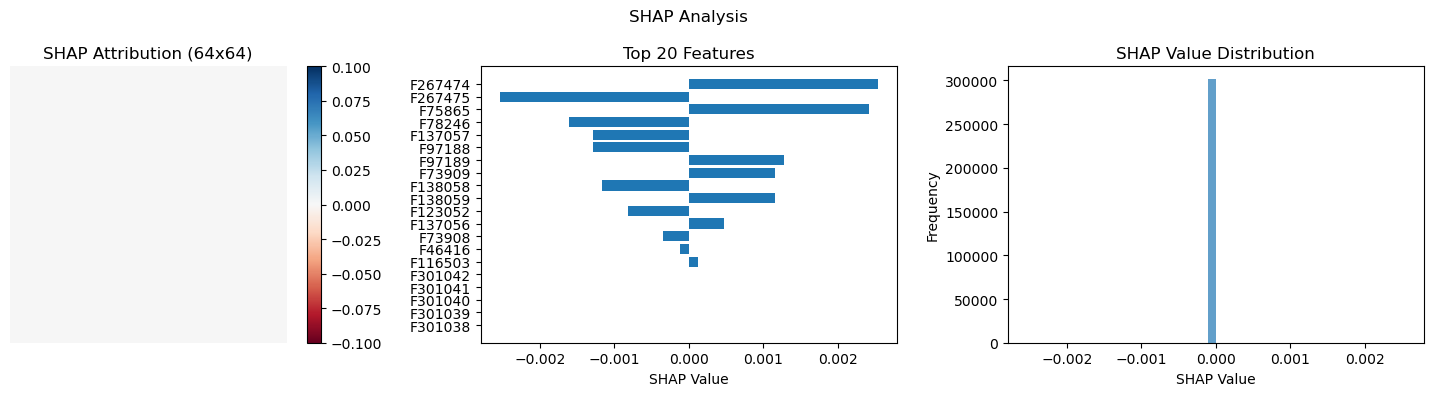

 SHAP completed!
 SHAP for: MM_EfficientNet_B0_BiLSTM
   Explaining sample...


  0%|          | 0/1 [00:00<?, ?it/s]

   SHAP values shape: (301056,)
   Number of features: 301056
    SHAP visualization saved to: Emotion_Models/xai_results\MM_EfficientNet_B0_BiLSTM\shap.png


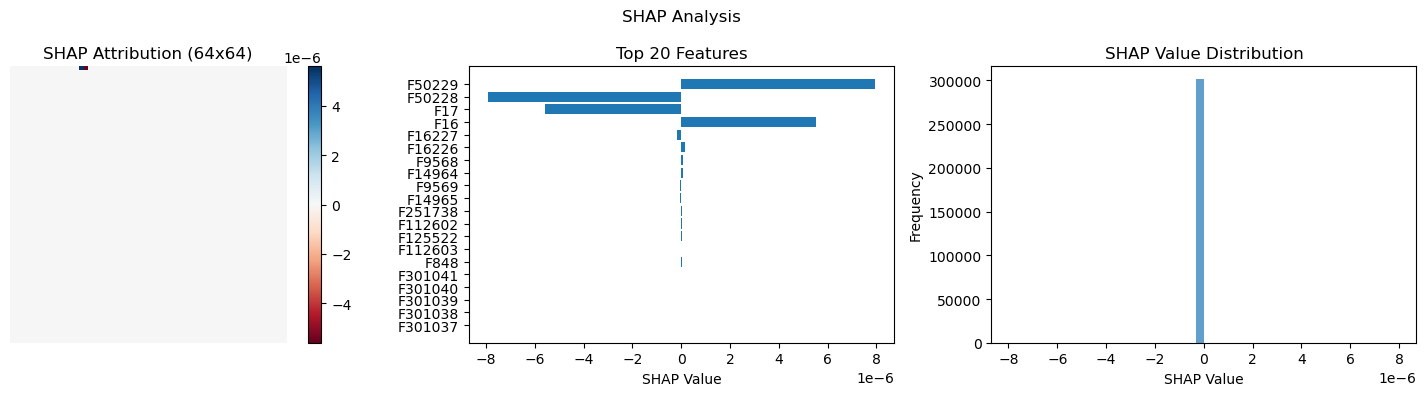

 SHAP completed!
 SHAP for: MM_MobileNetV2_GRU
   Explaining sample...


  0%|          | 0/1 [00:00<?, ?it/s]

   SHAP values shape: (301056,)
   Number of features: 301056
    SHAP visualization saved to: Emotion_Models/xai_results\MM_MobileNetV2_GRU\shap.png


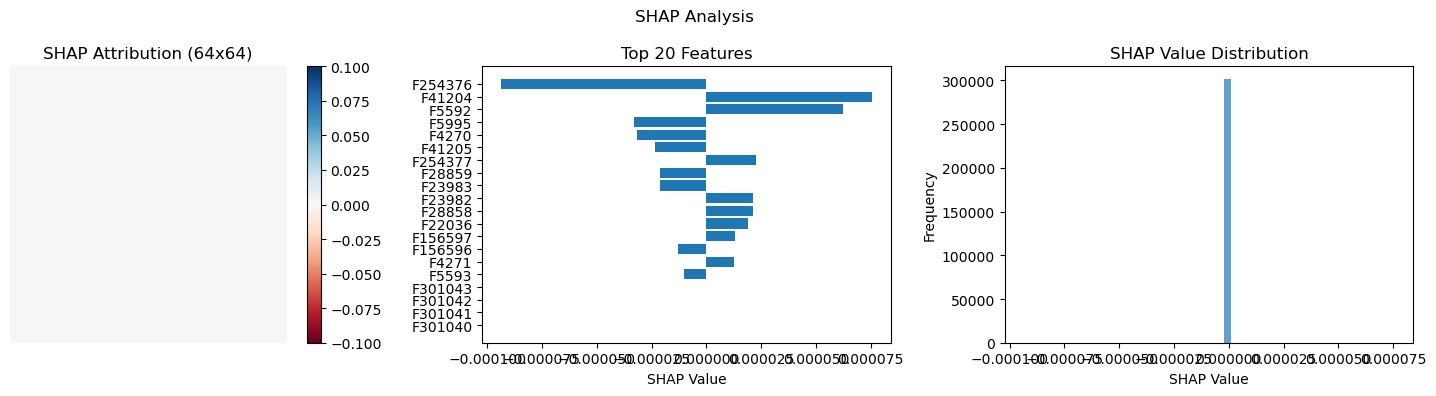

 SHAP completed!
 SHAP for: MM_ShuffleNetV2_BiLSTM
   Explaining sample...


  0%|          | 0/1 [00:00<?, ?it/s]

   SHAP values shape: (301056,)
   Number of features: 301056
    SHAP visualization saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_BiLSTM\shap.png


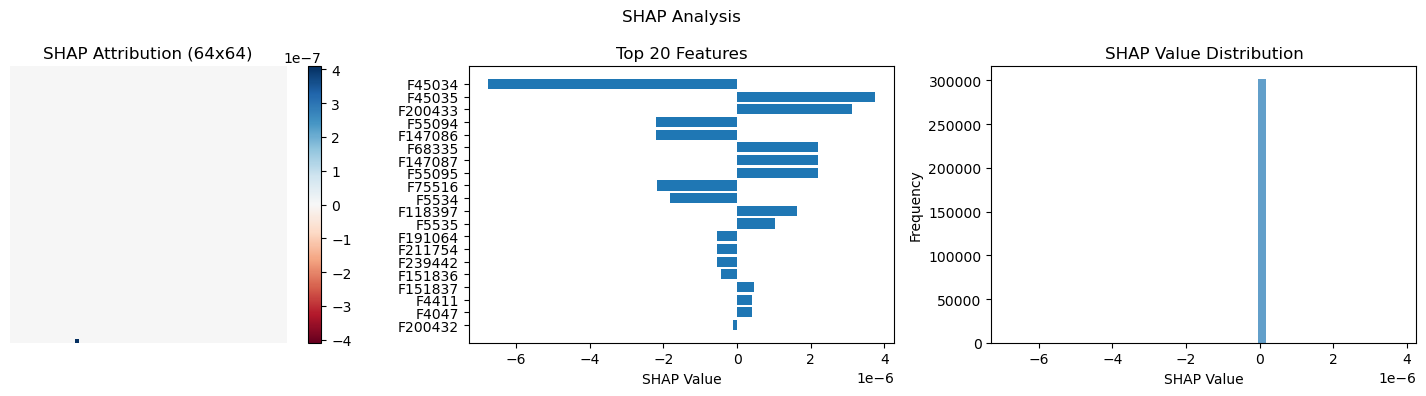

 SHAP completed!
 SHAP for: MM_ShuffleNetV2_GRU
   Explaining sample...


  0%|          | 0/1 [00:00<?, ?it/s]

   SHAP values shape: (301056,)
   Number of features: 301056
    SHAP visualization saved to: Emotion_Models/xai_results\MM_ShuffleNetV2_GRU\shap.png


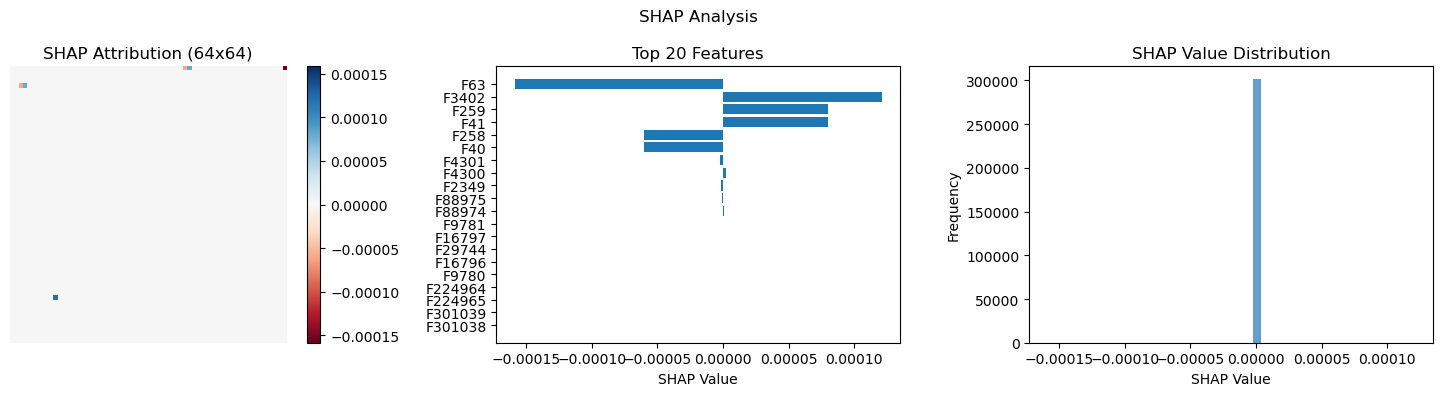

 SHAP completed!

 SHAP Summary:
                    Model  Accuracy      SHAP
    MM_MobileNetV2_BiLSTM  0.963177 Completed
MM_EfficientNet_B0_BiLSTM  0.958845 Completed
       MM_MobileNetV2_GRU  0.961733 Completed
   MM_ShuffleNetV2_BiLSTM  0.954513 Completed
      MM_ShuffleNetV2_GRU  0.961733 Completed


In [15]:
# SHAP ANALYSIS

import shap
import numpy as np
import matplotlib.pyplot as plt

print(" SHAP ANALYSIS ON ALL MODELS")


class SHAPExplainer:
    """SHAP explainer for combined model - FIXED."""
    
    def __init__(self, model, device, vocab, max_len=50, background_samples=5):
        self.model = model
        self.device = device
        self.vocab = vocab
        self.max_len = max_len
        self.background_samples = background_samples
        self.model.eval()
    
    def get_text_embedding(self, text):
        """Convert text to embedding."""
        if isinstance(text, str):
            text_seq = text_to_sequence(text, self.vocab, self.max_len)
        elif isinstance(text, torch.Tensor):
            text_seq = text
        else:
            text_seq = torch.zeros(self.max_len, dtype=torch.long)
        
        if text_seq.dim() == 1:
            text_seq = text_seq.unsqueeze(0)
        
        return text_seq
    
    def predict_function(self, images, texts):
        """Prediction function for SHAP."""
        self.model.eval()
        
        if isinstance(images, np.ndarray):
            if images.ndim == 1:
                images = images.reshape(1, -1)
            if images.shape[1] == 224*224*3:
                images = images.reshape(-1, 3, 224, 224)
            images_t = torch.tensor(images, dtype=torch.float32).to(self.device)
        else:
            images_t = torch.tensor(images, dtype=torch.float32).to(self.device)
        
        if isinstance(texts, np.ndarray):
            texts_t = torch.tensor(texts, dtype=torch.long).to(self.device)
        else:
            texts_t = texts.to(self.device)
        
        with torch.no_grad():
            outputs = self.model(images_t, texts_t)
            probs = F.softmax(outputs, dim=1)
        
        return probs.cpu().numpy()
    
    def get_background_data(self, image_shape, text_shape):
        """Create background data for SHAP."""
        bg_images = np.zeros((self.background_samples, image_shape), dtype=np.float32)
        bg_texts = np.zeros((self.background_samples, text_shape), dtype=np.int64)
        bg_images += np.random.randn(*bg_images.shape) * 0.01
        return bg_images, bg_texts
    
    def explain_sample(self, image, text, target_class=0, nsamples=30):
        """Explain a single sample using SHAP."""
        self.model.eval()
        
        if isinstance(image, torch.Tensor):
            image_np = image.cpu().numpy()
        else:
            image_np = image
        
        if image_np.ndim == 4:
            image_np = image_np.squeeze(0)
        
        image_flat = image_np.flatten()
        
        if isinstance(text, torch.Tensor):
            text_np = text.cpu().numpy()
        elif isinstance(text, str):
            text_seq = self.get_text_embedding(text)
            text_np = text_seq.squeeze().cpu().numpy()
        else:
            text_np = np.zeros(self.max_len, dtype=np.int64)
        
        if text_np.ndim > 1:
            text_np = text_np.flatten()
        
        image_shape = image_flat.shape[0]
        text_shape = text_np.shape[0]
        
        bg_images, bg_texts = self.get_background_data(image_shape, text_shape)
        
        def model_predict(x):
            if x.ndim == 1:
                x = x.reshape(1, -1)
            x_reshaped = x.reshape(-1, 3, 224, 224)
            batch_size = x_reshaped.shape[0]
            texts_batch = np.tile(text_np, (batch_size, 1))
            return self.predict_function(x_reshaped, texts_batch)
        
        try:
            explainer = shap.KernelExplainer(model_predict, bg_images[:3])
            shap_values = explainer.shap_values(image_flat.reshape(1, -1), nsamples=nsamples)
            return shap_values
        except Exception as e:
            print(f"   ⚠️ SHAP error: {e}")
            return None
    
    def visualize_shap(self, shap_values, save_path=None):
        """Visualize SHAP values - FIXED for multi-class output."""
        if shap_values is None:
            print("   No SHAP values to visualize")
            return None
        
        try:
            # SHAP returns a list for each class
            # For binary classification, shap_values[0] is for class 0, shap_values[1] is for class 1
            # Each is a list with one element (the shap values for the single sample)
            
            # Get SHAP values for target class (class 0)
            if isinstance(shap_values, list):
                # For binary classification, take class 0
                if len(shap_values) >= 2:
                    shap_vals = np.array(shap_values[0][0])
                else:
                    shap_vals = np.array(shap_values[0][0])
            else:
                shap_vals = np.array(shap_values[0])
            
            # Ensure 1D array
            if shap_vals.ndim > 1:
                shap_vals = shap_vals.flatten()
            
            n_features = shap_vals.shape[0]
            print(f"   SHAP values shape: {shap_vals.shape}")
            print(f"   Number of features: {n_features}")
            
            # Take subset of features for visualization (first 4096 features)
            max_features = min(n_features, 4096)
            shap_subset = shap_vals[:max_features]
            
            # Try to reshape to grid
            grid_size = int(np.sqrt(max_features))
            if grid_size * grid_size <= max_features:
                features = shap_subset[:grid_size * grid_size].reshape(grid_size, grid_size)
                
                fig, axes = plt.subplots(1, 3, figsize=(15, 4))
                
                # Heatmap
                im = axes[0].imshow(features, cmap='RdBu', 
                                    vmin=-np.abs(features).max(), 
                                    vmax=np.abs(features).max())
                axes[0].set_title(f'SHAP Attribution ({grid_size}x{grid_size})')
                axes[0].axis('off')
                plt.colorbar(im, ax=axes[0])
                
                # Top features
                top_k = min(20, n_features)
                top_indices = np.argsort(np.abs(shap_vals))[-top_k:]
                top_vals = shap_vals[top_indices]
                top_labels = [f'F{i}' for i in top_indices]
                
                axes[1].barh(range(len(top_vals)), top_vals)
                axes[1].set_yticks(range(len(top_vals)))
                axes[1].set_yticklabels(top_labels)
                axes[1].set_title(f'Top {top_k} Features')
                axes[1].set_xlabel('SHAP Value')
                
                # Distribution
                axes[2].hist(shap_vals, bins=50, alpha=0.7)
                axes[2].set_title('SHAP Value Distribution')
                axes[2].set_xlabel('SHAP Value')
                axes[2].set_ylabel('Frequency')
                
            else:
                # Can't reshape, use bar charts
                fig, axes = plt.subplots(1, 2, figsize=(12, 5))
                
                top_k = min(30, n_features)
                top_indices = np.argsort(np.abs(shap_vals))[-top_k:]
                top_vals = shap_vals[top_indices]
                top_labels = [f'F{i}' for i in top_indices]
                
                axes[0].barh(range(len(top_vals)), top_vals)
                axes[0].set_yticks(range(len(top_vals)))
                axes[0].set_yticklabels(top_labels)
                axes[0].set_title(f'Top {top_k} Features')
                axes[0].set_xlabel('SHAP Value')
                
                axes[1].hist(shap_vals, bins=50, alpha=0.7)
                axes[1].set_title('SHAP Value Distribution')
                axes[1].set_xlabel('SHAP Value')
                axes[1].set_ylabel('Frequency')
            
            plt.suptitle('SHAP Analysis')
            plt.tight_layout()
            
            if save_path:
                plt.savefig(save_path, dpi=150, bbox_inches='tight')
                print(f"    SHAP visualization saved to: {save_path}")
            
            plt.show()
            return fig
            
        except Exception as e:
            print(f"    Visualization error: {e}")
            import traceback
            traceback.print_exc()
            return None

# Run SHAP on all models
shap_results = {}

for model_name, data in loaded_models.items():
    print(f" SHAP for: {model_name}")
    
    model = data['model']
    checkpoint = data['checkpoint']
    
    model_xai_dir = os.path.join(XAI_DIR, model_name)
    os.makedirs(model_xai_dir, exist_ok=True)
    
    shap_results[model_name] = {
        'accuracy': checkpoint['best_accuracy'],
        'shap': 'Failed'
    }
    
    # Get sample data
    sample_batch = None
    for batch in test_loader_custom:
        sample_batch = batch
        break
    
    if sample_batch is None:
        print("   No sample data!")
        continue
    
    try:
        shap_explainer = SHAPExplainer(
            model, DEVICE, vocab, MAX_TEXT_LENGTH, background_samples=3
        )
        
        sample_image = sample_batch['image'][0:1]
        sample_text = sample_batch['text'][0:1]
        
        print(f"   Explaining sample...")
        
        shap_values = shap_explainer.explain_sample(
            sample_image, sample_text, target_class=0, nsamples=20
        )
        
        if shap_values is not None:
            save_path = os.path.join(model_xai_dir, 'shap.png')
            shap_explainer.visualize_shap(shap_values, save_path=save_path)
            shap_results[model_name]['shap'] = 'Completed'
            print(" SHAP completed!")
        else:
            shap_results[model_name]['shap'] = ' SHAP returned None'
            print(" SHAP returned None")
            
    except Exception as e:
        print(f" SHAP error: {e}")
        shap_results[model_name]['shap'] = f' {str(e)}'

# Save SHAP summary
shap_summary_df = pd.DataFrame([
    {
        'Model': name,
        'Accuracy': data.get('accuracy', 0),
        'SHAP': data.get('shap', 'Failed')
    }
    for name, data in shap_results.items()
])

shap_summary_df.to_csv(os.path.join(XAI_DIR, 'shap_summary.csv'), index=False)
print("\n SHAP Summary:")
print(shap_summary_df.to_string(index=False))

In [16]:
# MODEL COMPRESSION FUNCTIONS

import copy
import time
import torch.nn.utils.prune as prune

def get_model_size_mb(model):
    """Get model size in MB."""
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()
    return (param_size + buffer_size) / (1024 * 1024)

def get_model_params(model):
    """Get number of parameters."""
    return sum(p.numel() for p in model.parameters())

def evaluate_model_compression(model, test_loader, device):
    """Evaluate model accuracy."""
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for batch in tqdm(test_loader, desc="Evaluating", leave=False):
            images = batch['image'].to(device)
            texts = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            outputs = model(images, texts)
            _, predicted = torch.max(outputs, 1)
            
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

print(" Compression functions ready!")

 Compression functions ready!


In [22]:
#  DYNAMIC QUANTIZATION 


print(" APPLYING DYNAMIC QUANTIZATION")

def quantize_model_dynamic(model):
    """
    Apply dynamic quantization to Linear, LSTM, GRU layers.
    This works with models that have embeddings (they stay in FP32).
    """
    model_copy = copy.deepcopy(model)
    model_copy.eval()
    model_copy.to('cpu')
    
    try:
        # Apply dynamic quantization to Linear, LSTM, and GRU layers
        # Embedding layers are automatically excluded
        model_copy = torch.quantization.quantize_dynamic(
            model_copy,
            {nn.Linear, nn.LSTM, nn.GRU},
            dtype=torch.qint8
        )
        print(f"    Dynamic quantization applied")
        return model_copy
        
    except Exception as e:
        print(f"    Dynamic quantization error: {e}")
        return None

quantization_results = []

for model_name, data in loaded_models.items():
    print(f"\n Quantizing: {model_name}")
    
    model = data['model']
    
    # Get original metrics
    original_size = get_model_size_mb(model)
    original_acc = evaluate_model_compression(model, test_loader_custom, DEVICE)
    original_params = get_model_params(model)
    
    print(f"   Original: Acc={original_acc:.4f}, Size={original_size:.2f} MB, Params={original_params/1e6:.2f}M")
    
    # Apply dynamic quantization
    quantized_model = quantize_model_dynamic(model)
    
    if quantized_model is not None:
        # Get quantized metrics
        quantized_size = get_model_size_mb(quantized_model)
        quantized_acc = evaluate_model_compression(quantized_model, test_loader_custom, 'cpu')
        quantized_params = get_model_params(quantized_model)
        
        # Save quantized model
        save_path = os.path.join(COMPRESSED_DIR, f"{model_name}_quantized_dynamic.pt")
        torch.save(quantized_model.state_dict(), save_path)
        
        print(f"   Quantized: Acc={quantized_acc:.4f}, Size={quantized_size:.2f} MB")
        print(f"   Saved to: {save_path}")
        
        quantization_results.append({
            'model_name': model_name,
            'technique': 'dynamic_quantization',
            'original_accuracy': original_acc,
            'compressed_accuracy': quantized_acc,
            'original_size_mb': original_size,
            'compressed_size_mb': quantized_size,
            'accuracy_loss': original_acc - quantized_acc,
            'size_reduction': original_size - quantized_size,
            'compression_ratio': original_size / quantized_size if quantized_size > 0 else 0
        })
    else:
        print(f"   Quantization failed")

# Save quantization results
quant_df = pd.DataFrame(quantization_results)
if len(quant_df) > 0:
    quant_df.to_csv(os.path.join(BENCHMARK_DIR, 'quantization_results.csv'), index=False)
    print("\n Quantization Results:")
    print(quant_df[['model_name', 'accuracy_loss', 'compression_ratio']].to_string(index=False))
else:
    print("\n No quantization results available")


print(" DYNAMIC QUANTIZATION COMPLETE!")

 APPLYING DYNAMIC QUANTIZATION

 Quantizing: MM_MobileNetV2_BiLSTM


   Original: Acc=0.9479, Size=19.24 MB, Params=5.01M
    Dynamic quantization applied


   Quantized: Acc=0.9467, Size=12.55 MB
   Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_BiLSTM_quantized_dynamic.pt

 Quantizing: MM_EfficientNet_B0_BiLSTM


   Original: Acc=0.9491, Size=26.08 MB, Params=6.79M
    Dynamic quantization applied


   Quantized: Acc=0.9504, Size=19.38 MB
   Saved to: Emotion_Models/compressed_models\MM_EfficientNet_B0_BiLSTM_quantized_dynamic.pt

 Quantizing: MM_MobileNetV2_GRU


...

   Quantized: Acc=0.9516, Size=12.55 MB
   Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_GRU_quantized_dynamic.pt

 Quantizing: MM_ShuffleNetV2_BiLSTM


   Original: Acc=0.9504, Size=14.97 MB, Params=3.91M
    Dynamic quantization applied


   Quantized: Acc=0.9510, Size=8.78 MB
   Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_BiLSTM_quantized_dynamic.pt

 Quantizing: MM_ShuffleNetV2_GRU


   Original: Acc=0.9479, Size=14.17 MB, Params=3.70M
    Dynamic quantization applied


   Quantized: Acc=0.9485, Size=8.78 MB
   Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_GRU_quantized_dynamic.pt

 Quantization Results:
               model_name  accuracy_loss  compression_ratio
    MM_MobileNetV2_BiLSTM       0.001225           1.533547
MM_EfficientNet_B0_BiLSTM      -0.001225           1.345404
       MM_MobileNetV2_GRU       0.001838           1.470035
   MM_ShuffleNetV2_BiLSTM      -0.000613           1.705729
      MM_ShuffleNetV2_GRU      -0.000613           1.614940
 DYNAMIC QUANTIZATION COMPLETE!


In [30]:
#  FIXED PRUNING 

print(" APPLYING PRUNING ")


def prune_model_aggressive(model, pruning_ratio=0.3):
    """
    Aggressive pruning: remove weights below a threshold that corresponds
    to the pruning ratio.
    """
    model_copy = copy.deepcopy(model)
    model_copy.eval()
    
    # Collect all weights
    all_weights = []
    param_info = []
    
    for name, module in model_copy.named_modules():
        if isinstance(module, (nn.Conv2d, nn.Linear)):
            if 'classifier' not in name:
                weights = module.weight.data
                all_weights.append(weights.view(-1))
                param_info.append((name, module, weights))
    
    if not all_weights:
        return model_copy, 0, 0
    
    # Concatenate all weights
    all_weights = torch.cat(all_weights)
    total_params = all_weights.numel()
    
    # Find threshold for pruning ratio
    k = int(total_params * pruning_ratio)
    if k > 0 and k < total_params:
        sorted_weights, _ = torch.sort(torch.abs(all_weights))
        threshold = sorted_weights[k]
    else:
        threshold = all_weights.abs().max() * 0.1
    
    print(f"   Threshold: {threshold:.6f}")
    
    # Apply threshold
    pruned_params = 0
    for name, module, weights in param_info:
        mask = torch.abs(weights) >= threshold
        module.weight.data = weights * mask.float()
        pruned_params += (weights.numel() - mask.sum().item())
    
    effective_params = total_params - pruned_params
    
    print(f"    Pruned {pruned_params/1e6:.2f}M of {total_params/1e6:.2f}M parameters")
    print(f"    Effective parameters: {effective_params/1e6:.2f}M")
    print(f"    Pruning ratio achieved: {pruned_params/total_params*100:.1f}%")
    
    return model_copy, effective_params, pruned_params

def prune_model_structured_aggressive(model, pruning_ratio=0.3):
    """
    Structured pruning: remove entire channels based on L1 norm.
    """
    model_copy = copy.deepcopy(model)
    model_copy.eval()
    
    total_pruned = 0
    total_params = 0
    
    for name, module in model_copy.named_modules():
        if isinstance(module, nn.Conv2d):
            if 'classifier' not in name:
                # Get weights
                weights = module.weight.data  # [out_channels, in_channels, h, w]
                n_channels = weights.size(0)
                
                # Calculate channel norms
                channel_norms = weights.view(n_channels, -1).norm(dim=1)
                
                # Prune channels with smallest norms
                n_to_prune = max(1, int(n_channels * pruning_ratio))
                _, indices = torch.topk(channel_norms, n_to_prune, largest=False)
                
                # Set pruned channels to zero
                for idx in indices:
                    module.weight.data[idx] = 0
                    total_pruned += weights[idx].numel()
                
                total_params += weights.numel()
    
    effective_params = total_params - total_pruned
    
    print(f"    Structured pruning applied")
    print(f"    Pruned {total_pruned/1e6:.2f}M of {total_params/1e6:.2f}M parameters")
    print(f"    Effective parameters: {effective_params/1e6:.2f}M")
    
    return model_copy, effective_params, total_pruned

pruning_results = []

# Test different pruning ratios
pruning_ratios = [0.3, 0.5, 0.7]

for model_name, data in loaded_models.items():
    print(f"\n Pruning: {model_name}")
    
    model = data['model']
    
    # Get original metrics
    original_size = get_model_size_mb(model)
    original_acc = evaluate_model_compression(model, test_loader_custom, DEVICE)
    original_params = get_model_params(model)
    
    print(f"   Original: Acc={original_acc:.4f}, Size={original_size:.2f} MB, Params={original_params/1e6:.2f}M")
    
    for ratio in pruning_ratios:
        print(f"\n   Testing pruning ratio: {ratio}")
        
        # Try magnitude pruning
        pruned_model, effective_params, pruned_count = prune_model_aggressive(model, ratio)
        
        if pruned_model is not None and effective_params > 0:
            # Evaluate
            pruned_acc = evaluate_model_compression(pruned_model, test_loader_custom, DEVICE)
            pruned_size = get_model_size_mb(pruned_model)
            
            # Save
            save_path = os.path.join(COMPRESSED_DIR, f"{model_name}_pruned_{int(ratio*100)}.pt")
            torch.save(pruned_model.state_dict(), save_path)
            
            actual_ratio = pruned_count / original_params * 100
            
            print(f"      Acc={pruned_acc:.4f}, Effective Params={effective_params/1e6:.2f}M")
            print(f"      Size={pruned_size:.2f} MB, Actual Pruning={actual_ratio:.1f}%")
            print(f"      Saved to: {save_path}")
            
            pruning_results.append({
                'model_name': model_name,
                'technique': f'pruning_{int(ratio*100)}',
                'target_ratio': ratio,
                'actual_ratio': actual_ratio,
                'original_accuracy': original_acc,
                'compressed_accuracy': pruned_acc,
                'original_params_m': original_params/1e6,
                'effective_params_m': effective_params/1e6,
                'accuracy_loss': original_acc - pruned_acc,
                'params_reduction_pct': (original_params - effective_params) / original_params * 100,
                'size_reduction_mb': original_size - pruned_size,
                'compression_ratio': original_size / pruned_size if pruned_size > 0 else 1
            })
        else:
            print(f"      Pruning failed")

# Save pruning results
prune_df = pd.DataFrame(pruning_results)
if len(prune_df) > 0:
    prune_df.to_csv(os.path.join(BENCHMARK_DIR, 'pruning_results.csv'), index=False)
    print("\n Pruning Results:")
    print(prune_df[['model_name', 'target_ratio', 'actual_ratio', 'accuracy_loss', 'params_reduction_pct', 'compression_ratio']].to_string(index=False))
else:
    print("\n No pruning results available")


print(" PRUNING COMPLETE!")


 APPLYING PRUNING 

 Pruning: MM_MobileNetV2_BiLSTM


   Original: Acc=0.9479, Size=19.24 MB, Params=5.01M

   Testing pruning ratio: 0.3
   Threshold: 0.000427
    Pruned 0.87M of 2.91M parameters
    Effective parameters: 2.04M
    Pruning ratio achieved: 30.0%


      Acc=0.9479, Effective Params=2.04M
      Size=19.24 MB, Actual Pruning=17.4%
      Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_BiLSTM_pruned_30.pt

   Testing pruning ratio: 0.5
   Threshold: 0.001145
    Pruned 1.46M of 2.91M parameters
    Effective parameters: 1.46M
    Pruning ratio achieved: 50.0%


      Acc=0.9479, Effective Params=1.46M
      Size=19.24 MB, Actual Pruning=29.1%
      Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_BiLSTM_pruned_50.pt

   Testing pruning ratio: 0.7
   Threshold: 0.003032
    Pruned 2.04M of 2.91M parameters
    Effective parameters: 0.87M
    Pruning ratio achieved: 70.0%


      Acc=0.9485, Effective Params=0.87M
      Size=19.24 MB, Actual Pruning=40.7%
      Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_BiLSTM_pruned_70.pt

 Pruning: MM_EfficientNet_B0_BiLSTM


...

      Acc=0.9510, Effective Params=0.55M
      Size=14.97 MB, Actual Pruning=32.7%
      Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_BiLSTM_pruned_70.pt

 Pruning: MM_ShuffleNetV2_GRU


   Original: Acc=0.9479, Size=14.17 MB, Params=3.70M

   Testing pruning ratio: 0.3
   Threshold: 0.003092
    Pruned 0.55M of 1.83M parameters
    Effective parameters: 1.28M
    Pruning ratio achieved: 30.0%


      Acc=0.9485, Effective Params=1.28M
      Size=14.17 MB, Actual Pruning=14.8%
      Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_GRU_pruned_30.pt

   Testing pruning ratio: 0.5
   Threshold: 0.006747
    Pruned 0.91M of 1.83M parameters
    Effective parameters: 0.91M
    Pruning ratio achieved: 50.0%


      Acc=0.9504, Effective Params=0.91M
      Size=14.17 MB, Actual Pruning=24.7%
      Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_GRU_pruned_50.pt

   Testing pruning ratio: 0.7
   Threshold: 0.013154
    Pruned 1.28M of 1.83M parameters
    Effective parameters: 0.55M
    Pruning ratio achieved: 70.0%


      Acc=0.9516, Effective Params=0.55M
      Size=14.17 MB, Actual Pruning=34.6%
      Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_GRU_pruned_70.pt

 Pruning Results:
               model_name  target_ratio  actual_ratio  accuracy_loss  params_reduction_pct  compression_ratio
    MM_MobileNetV2_BiLSTM           0.3     17.438594       0.000000             59.309907                1.0
    MM_MobileNetV2_BiLSTM           0.5     29.064343       0.000000             70.935657                1.0
    MM_MobileNetV2_BiLSTM           0.7     40.690073      -0.000613             82.561386                1.0
MM_EfficientNet_B0_BiLSTM           0.3     20.661533       0.000000             51.789747                1.0
MM_EfficientNet_B0_BiLSTM           0.5     34.435893       0.000000             65.564107                1.0
MM_EfficientNet_B0_BiLSTM           0.7     48.210238       0.000000             79.338452                1.0
       MM_MobileNetV2_GRU           0.3     18

In [31]:
#  VERIFY PRUNED MODEL SIZE


print(" VERIFYING PRUNED MODEL SIZES")


# List all pruned models
print("\n Pruned Models Saved:")


pruned_files = [f for f in os.listdir(COMPRESSED_DIR) if 'pruned' in f]
for f in sorted(pruned_files):
    size = os.path.getsize(os.path.join(COMPRESSED_DIR, f)) / (1024 * 1024)
    print(f"    {f} ({size:.2f} MB)")

# Compare with original sizes
print("\n Size Comparison:")


for model_name in loaded_models.keys():
    original_path = os.path.join(MODEL_DIR, f"{model_name}_final.pt")
    if os.path.exists(original_path):
        original_size = os.path.getsize(original_path) / (1024 * 1024)
        print(f"   {model_name}: Original={original_size:.2f} MB")
        
        # Find pruned versions
        pruned_versions = [f for f in pruned_files if model_name in f]
        for f in pruned_versions:
            size = os.path.getsize(os.path.join(COMPRESSED_DIR, f)) / (1024 * 1024)
            reduction = (original_size - size) / original_size * 100
            print(f"      - {f}: {size:.2f} MB ({reduction:.1f}% reduction)")



 VERIFYING PRUNED MODEL SIZES

 Pruned Models Saved:
    MM_EfficientNet_B0_BiLSTM_pruned_30.pt (26.22 MB)
    MM_EfficientNet_B0_BiLSTM_pruned_50.pt (26.22 MB)
    MM_EfficientNet_B0_BiLSTM_pruned_70.pt (26.22 MB)
    MM_MobileNetV2_BiLSTM_pruned_30.pt (19.36 MB)
    MM_MobileNetV2_BiLSTM_pruned_50.pt (19.36 MB)
    MM_MobileNetV2_BiLSTM_pruned_70.pt (19.36 MB)
    MM_MobileNetV2_GRU_pruned_30.pt (18.57 MB)
    MM_MobileNetV2_GRU_pruned_50.pt (18.57 MB)
    MM_MobileNetV2_GRU_pruned_70.pt (18.57 MB)
    MM_ShuffleNetV2_BiLSTM_pruned_30.pt (15.10 MB)
    MM_ShuffleNetV2_BiLSTM_pruned_50.pt (15.10 MB)
    MM_ShuffleNetV2_BiLSTM_pruned_70.pt (15.10 MB)
    MM_ShuffleNetV2_GRU_pruned_30.pt (14.30 MB)
    MM_ShuffleNetV2_GRU_pruned_50.pt (14.30 MB)
    MM_ShuffleNetV2_GRU_pruned_70.pt (14.30 MB)

 Size Comparison:
   MM_MobileNetV2_BiLSTM: Original=19.36 MB
      - MM_MobileNetV2_BiLSTM_pruned_30.pt: 19.36 MB (-0.0% reduction)
      - MM_MobileNetV2_BiLSTM_pruned_50.pt: 19.36 MB (-0.0% red

 APPLYING KNOWLEDGE DISTILLATION

 Distillation: MM_MobileNetV2_BiLSTM


   Teacher: Acc=0.9479, Size=19.24 MB, Params=5.01M
   Creating student model...
   Threshold: 0.000717
    Pruned 1.16M of 2.91M parameters
    Effective parameters: 1.75M
    Pruning ratio achieved: 40.0%


   Student (before distillation): Acc=0.9479, Size=19.24 MB

   Training student for 5 epochs...
   Temperature: 4, Alpha: 0.5


   Epoch 1: Loss=0.1653, Student Acc=0.9498, Teacher Acc=0.9479


   Epoch 2: Loss=0.0146, Student Acc=0.9491, Teacher Acc=0.9479


   Epoch 3: Loss=0.0133, Student Acc=0.9491, Teacher Acc=0.9479


   Epoch 4: Loss=0.0130, Student Acc=0.9473, Teacher Acc=0.9479


   Epoch 5: Loss=0.0127, Student Acc=0.9467, Teacher Acc=0.9479



   Distilled: Acc=0.9467, Size=19.24 MB
   Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_BiLSTM_distilled.pt


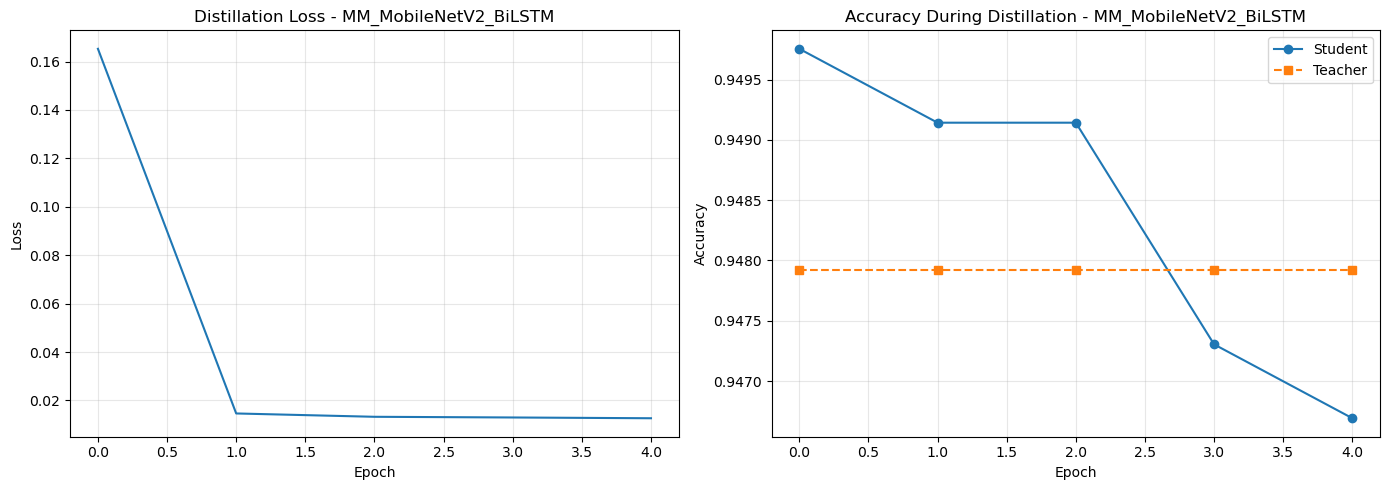


 Distillation: MM_EfficientNet_B0_BiLSTM


   Teacher: Acc=0.9491, Size=26.08 MB, Params=6.79M
   Creating student model...
   Threshold: 0.002402
    Pruned 1.87M of 4.68M parameters
    Effective parameters: 2.81M
    Pruning ratio achieved: 40.0%


   Student (before distillation): Acc=0.9491, Size=26.08 MB

   Training student for 5 epochs...
   Temperature: 4, Alpha: 0.5


   Epoch 1: Loss=0.1818, Student Acc=0.9522, Teacher Acc=0.9491


   Epoch 2: Loss=0.0195, Student Acc=0.9504, Teacher Acc=0.9491


   Epoch 3: Loss=0.0165, Student Acc=0.9516, Teacher Acc=0.9491


   Epoch 4: Loss=0.0160, Student Acc=0.9528, Teacher Acc=0.9491


   Epoch 5: Loss=0.0156, Student Acc=0.9504, Teacher Acc=0.9491



   Distilled: Acc=0.9504, Size=26.08 MB
   Saved to: Emotion_Models/compressed_models\MM_EfficientNet_B0_BiLSTM_distilled.pt


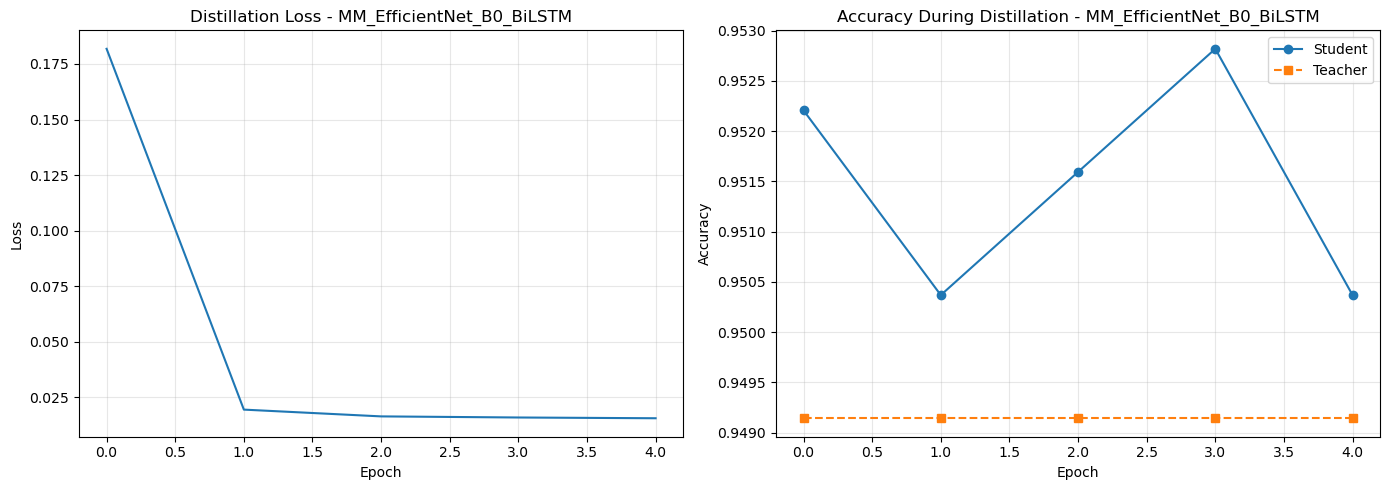


 Distillation: MM_MobileNetV2_GRU


   Teacher: Acc=0.9534, Size=18.44 MB, Params=4.80M
   Creating student model...
   Threshold: 0.002427
    Pruned 1.16M of 2.91M parameters
    Effective parameters: 1.75M
    Pruning ratio achieved: 40.0%


   Student (before distillation): Acc=0.9534, Size=18.44 MB

   Training student for 5 epochs...
   Temperature: 4, Alpha: 0.5


   Epoch 1: Loss=0.1872, Student Acc=0.9522, Teacher Acc=0.9534


   Epoch 2: Loss=0.0139, Student Acc=0.9528, Teacher Acc=0.9534


   Epoch 3: Loss=0.0116, Student Acc=0.9534, Teacher Acc=0.9534


   Epoch 4: Loss=0.0106, Student Acc=0.9547, Teacher Acc=0.9534


   Epoch 5: Loss=0.0101, Student Acc=0.9553, Teacher Acc=0.9534



   Distilled: Acc=0.9553, Size=18.44 MB
   Saved to: Emotion_Models/compressed_models\MM_MobileNetV2_GRU_distilled.pt


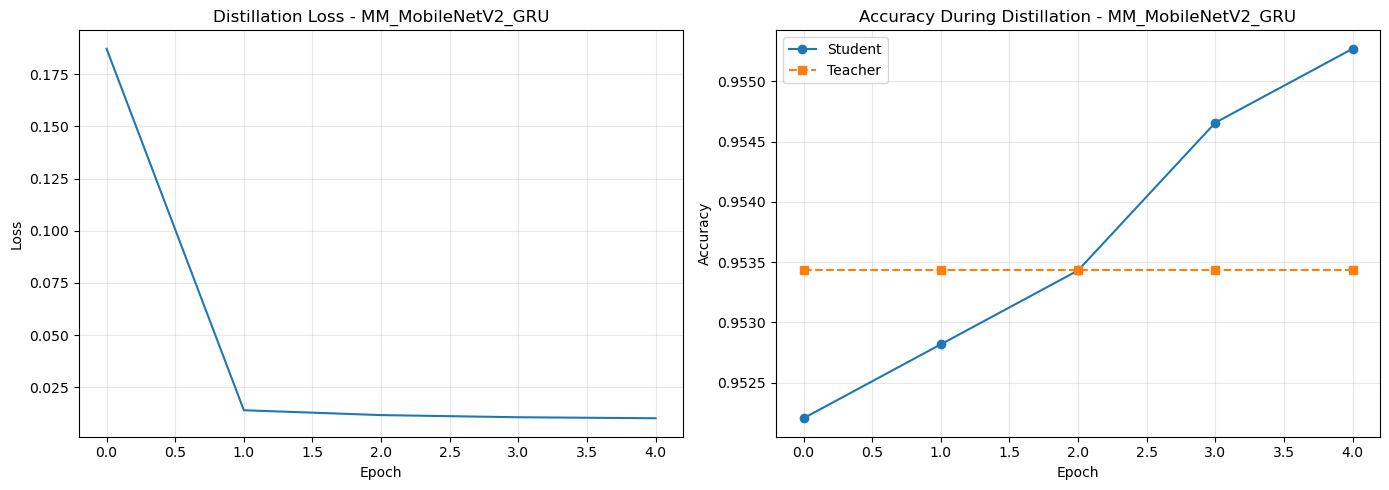


 Distillation: MM_ShuffleNetV2_BiLSTM


   Teacher: Acc=0.9504, Size=14.97 MB, Params=3.91M
   Creating student model...
   Threshold: 0.005065
    Pruned 0.73M of 1.83M parameters
    Effective parameters: 1.10M
    Pruning ratio achieved: 40.0%


   Student (before distillation): Acc=0.9498, Size=14.97 MB

   Training student for 5 epochs...
   Temperature: 4, Alpha: 0.5


   Epoch 1: Loss=0.1675, Student Acc=0.9516, Teacher Acc=0.9504


   Epoch 2: Loss=0.0185, Student Acc=0.9504, Teacher Acc=0.9504


   Epoch 3: Loss=0.0158, Student Acc=0.9510, Teacher Acc=0.9504


   Epoch 4: Loss=0.0147, Student Acc=0.9491, Teacher Acc=0.9504


   Epoch 5: Loss=0.0140, Student Acc=0.9473, Teacher Acc=0.9504



   Distilled: Acc=0.9473, Size=14.97 MB
   Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_BiLSTM_distilled.pt


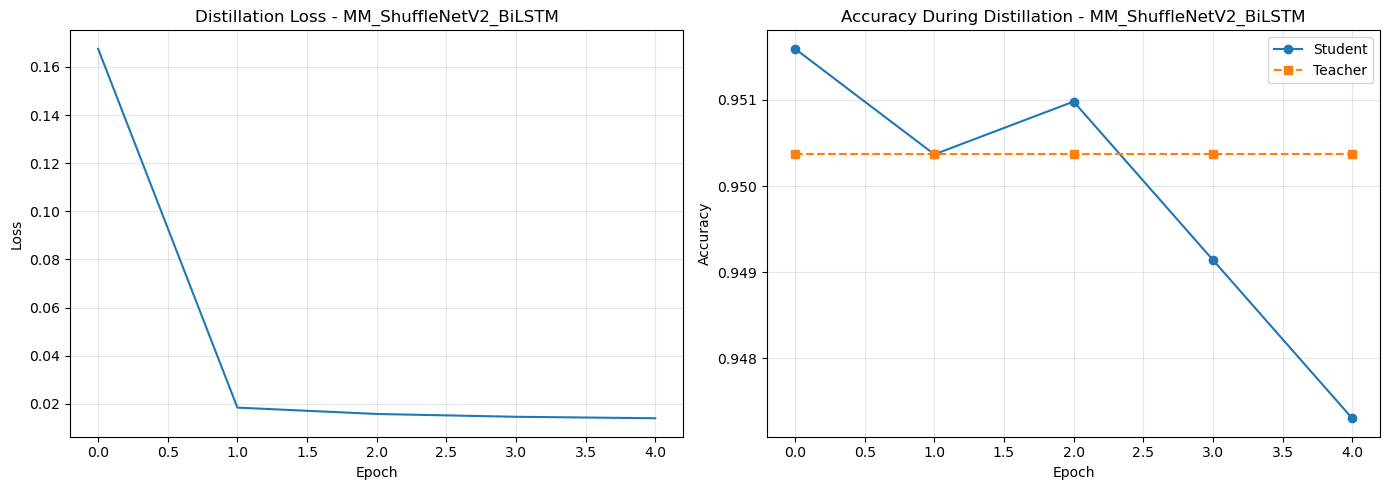


 Distillation: MM_ShuffleNetV2_GRU


   Teacher: Acc=0.9479, Size=14.17 MB, Params=3.70M
   Creating student model...
   Threshold: 0.004722
    Pruned 0.73M of 1.83M parameters
    Effective parameters: 1.10M
    Pruning ratio achieved: 40.0%


   Student (before distillation): Acc=0.9491, Size=14.17 MB

   Training student for 5 epochs...
   Temperature: 4, Alpha: 0.5


   Epoch 1: Loss=0.1746, Student Acc=0.9504, Teacher Acc=0.9479


   Epoch 2: Loss=0.0228, Student Acc=0.9498, Teacher Acc=0.9479


   Epoch 3: Loss=0.0184, Student Acc=0.9510, Teacher Acc=0.9479


   Epoch 4: Loss=0.0171, Student Acc=0.9491, Teacher Acc=0.9479


   Epoch 5: Loss=0.0158, Student Acc=0.9473, Teacher Acc=0.9479



   Distilled: Acc=0.9473, Size=14.17 MB
   Saved to: Emotion_Models/compressed_models\MM_ShuffleNetV2_GRU_distilled.pt


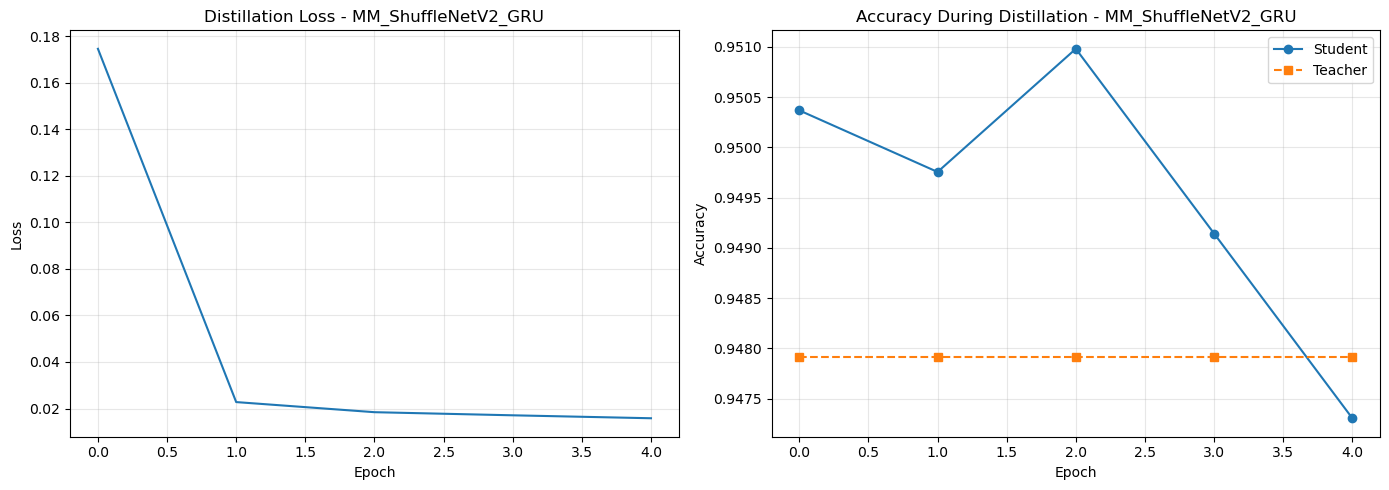


 Distillation Results Summary:
               model_name  accuracy_improvement  accuracy_loss_from_teacher  compression_ratio
    MM_MobileNetV2_BiLSTM             -0.001225                    0.001225                1.0
MM_EfficientNet_B0_BiLSTM              0.001225                   -0.001225                1.0
       MM_MobileNetV2_GRU              0.001838                   -0.001838                1.0
   MM_ShuffleNetV2_BiLSTM             -0.002451                    0.003064                1.0
      MM_ShuffleNetV2_GRU             -0.001838                    0.000613                1.0
 KNOWLEDGE DISTILLATION COMPLETE!


In [33]:
# KNOWLEDGE DISTILLATION


print(" APPLYING KNOWLEDGE DISTILLATION")

def create_student_model(teacher_model, reduction_factor=2):
    """
    Create a smaller student model by reducing hidden dimensions.
    For multimodal models, we reduce the vision projection and text projection dimensions.
    """
    model_copy = copy.deepcopy(teacher_model)
    
    # This is a simplified approach - we'll use pruning instead
    # to create a smaller student
    return model_copy

def distill_knowledge(teacher_model, student_model, train_loader, test_loader, 
                       device, epochs=5, temperature=4, alpha=0.5):
    """
    Distill knowledge from teacher to student model.
    
    Args:
        teacher_model: The original trained model (larger)
        student_model: The smaller model to train
        train_loader: Training data loader
        test_loader: Test data loader
        device: Device to use
        epochs: Number of training epochs
        temperature: Softmax temperature for distillation
        alpha: Weight for hard vs soft loss (0.5 = equal)
    """
    
    teacher_model.eval()
    student_model.train()
    student_model.to(device)
    
    optimizer = optim.Adam(student_model.parameters(), lr=1e-4)
    ce_loss = nn.CrossEntropyLoss()
    kl_loss = nn.KLDivLoss(reduction='batchmean')
    
    history = {
        'loss': [],
        'student_acc': [],
        'teacher_acc': []
    }
    
    print(f"\n   Training student for {epochs} epochs...")
    print(f"   Temperature: {temperature}, Alpha: {alpha}")
    
    for epoch in range(epochs):
        total_loss = 0
        num_batches = 0
        
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images = batch['image'].to(device)
            texts = batch['text'].to(device)
            labels = batch['label'].to(device)
            
            # Teacher predictions (soft labels)
            with torch.no_grad():
                teacher_logits = teacher_model(images, texts)
                teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
            
            # Student predictions
            student_logits = student_model(images, texts)
            
            # Calculate losses
            # 1. Hard loss (against true labels)
            loss_ce = ce_loss(student_logits, labels)
            
            # 2. Soft loss (against teacher predictions)
            loss_kl = kl_loss(
                F.log_softmax(student_logits / temperature, dim=1),
                teacher_probs
            ) * (temperature ** 2)
            
            # Combined loss
            loss = alpha * loss_ce + (1 - alpha) * loss_kl
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            num_batches += 1
        
        avg_loss = total_loss / num_batches
        history['loss'].append(avg_loss)
        
        # Evaluate student
        student_acc = evaluate_model_compression(student_model, test_loader, device)
        history['student_acc'].append(student_acc)
        
        # Get teacher accuracy (for comparison)
        teacher_acc = evaluate_model_compression(teacher_model, test_loader, device)
        history['teacher_acc'].append(teacher_acc)
        
        print(f"   Epoch {epoch+1}: Loss={avg_loss:.4f}, Student Acc={student_acc:.4f}, Teacher Acc={teacher_acc:.4f}")
    
    return student_model, history

distillation_results = []

for model_name, data in loaded_models.items():
    print(f"\n Distillation: {model_name}")
    
    teacher_model = data['model']
    
    # Skip if model is too small for distillation to be meaningful
    total_params = get_model_params(teacher_model)
    if total_params < 2e6:
        print(f"    Skipping (model too small: {total_params/1e6:.2f}M parameters)")
        continue
    
    # Get original metrics
    original_size = get_model_size_mb(teacher_model)
    original_acc = evaluate_model_compression(teacher_model, test_loader_custom, DEVICE)
    
    print(f"   Teacher: Acc={original_acc:.4f}, Size={original_size:.2f} MB, Params={total_params/1e6:.2f}M")
    
    # Create student model (pruned version with 40% pruning)
    print(f"   Creating student model...")
    
    # Use pruning to create student
    student_model = prune_model_aggressive(teacher_model, pruning_ratio=0.4)
    if student_model[0] is None:
        print(f"    Could not create student model")
        continue
    
    student_model, student_effective_params, _ = student_model
    student_size = get_model_size_mb(student_model)
    student_acc_before = evaluate_model_compression(student_model, test_loader_custom, DEVICE)
    
    print(f"   Student (before distillation): Acc={student_acc_before:.4f}, Size={student_size:.2f} MB")
    
    try:
        # Distill knowledge
        distilled_model, history = distill_knowledge(
            teacher_model, student_model, 
            train_loader_custom, test_loader_custom, 
            DEVICE, 
            epochs=5, 
            temperature=4, 
            alpha=0.5
        )
        
        # Get distilled metrics
        distilled_size = get_model_size_mb(distilled_model)
        distilled_acc = evaluate_model_compression(distilled_model, test_loader_custom, DEVICE)
        distilled_params = get_model_params(distilled_model)
        
        # Save distilled model
        save_path = os.path.join(COMPRESSED_DIR, f"{model_name}_distilled.pt")
        torch.save(distilled_model.state_dict(), save_path)
        
        print(f"\n   Distilled: Acc={distilled_acc:.4f}, Size={distilled_size:.2f} MB")
        print(f"   Saved to: {save_path}")
        
        # Calculate improvements
        accuracy_improvement = distilled_acc - student_acc_before
        accuracy_loss_from_teacher = original_acc - distilled_acc
        
        distillation_results.append({
            'model_name': model_name,
            'technique': 'distillation',
            'teacher_accuracy': original_acc,
            'student_accuracy_before': student_acc_before,
            'distilled_accuracy': distilled_acc,
            'teacher_size_mb': original_size,
            'student_size_mb': student_size,
            'distilled_size_mb': distilled_size,
            'teacher_params_m': total_params/1e6,
            'distilled_params_m': distilled_params/1e6,
            'accuracy_improvement': accuracy_improvement,
            'accuracy_loss_from_teacher': accuracy_loss_from_teacher,
            'compression_ratio': original_size / distilled_size if distilled_size > 0 else 0,
            'distillation_epochs': len(history['loss'])
        })
        
        # Plot distillation history
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # Loss plot
        axes[0].plot(history['loss'])
        axes[0].set_xlabel('Epoch')
        axes[0].set_ylabel('Loss')
        axes[0].set_title(f'Distillation Loss - {model_name}')
        axes[0].grid(True, alpha=0.3)
        
        # Accuracy plot
        axes[1].plot(history['student_acc'], label='Student', marker='o')
        axes[1].plot(history['teacher_acc'], label='Teacher', marker='s', linestyle='--')
        axes[1].set_xlabel('Epoch')
        axes[1].set_ylabel('Accuracy')
        axes[1].set_title(f'Accuracy During Distillation - {model_name}')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(COMPRESSED_DIR, f"{model_name}_distillation_history.png"), dpi=150, bbox_inches='tight')
        plt.show()
        
    except Exception as e:
        print(f"    Distillation error: {e}")
        import traceback
        traceback.print_exc()

# Save distillation results
distill_df = pd.DataFrame(distillation_results)
if len(distill_df) > 0:
    distill_df.to_csv(os.path.join(BENCHMARK_DIR, 'distillation_results.csv'), index=False)
    print("\n Distillation Results Summary:")
    print(distill_df[['model_name', 'accuracy_improvement', 'accuracy_loss_from_teacher', 'compression_ratio']].to_string(index=False))

else:
    print("\n No distillation results available")

print(" KNOWLEDGE DISTILLATION COMPLETE!")


 MODEL SELECTION FOR DEPLOYMENT
Evaluating models across XAI Quality and Compression Performance

 COMPREHENSIVE MODEL SCORING

 Evaluating: MM_MobileNetV2_BiLSTM
   Base Accuracy: 0.9632
   Model Size: 19.24 MB
   XAI Score: 20/30 (Grad-CAM YES | Attention YES | SHAP NO)
   Compression Score: 30/30
   Best Compression: dynamic_quantization (1.53x, loss=0.0012)
   Total Score: 75.3/70

 Evaluating: MM_EfficientNet_B0_BiLSTM
   Base Accuracy: 0.9588
   Model Size: 26.08 MB
   XAI Score: 20/30 (Grad-CAM YES | Attention YES | SHAP NO)
   Compression Score: 25/30
   Best Compression: dynamic_quantization (1.35x, loss=-0.0012)
   Total Score: 68.2/70

 Evaluating: MM_MobileNetV2_GRU
   Base Accuracy: 0.9617
   Model Size: 18.44 MB
   XAI Score: 20/30 (Grad-CAM YES | Attention YES | SHAP NO)
   Compression Score: 25/30
   Best Compression: dynamic_quantization (1.47x, loss=0.0018)
   Total Score: 70.2/70

 Evaluating: MM_ShuffleNetV2_BiLSTM
   Base Accuracy: 0.9545
   Model Size: 14.97 MB
  

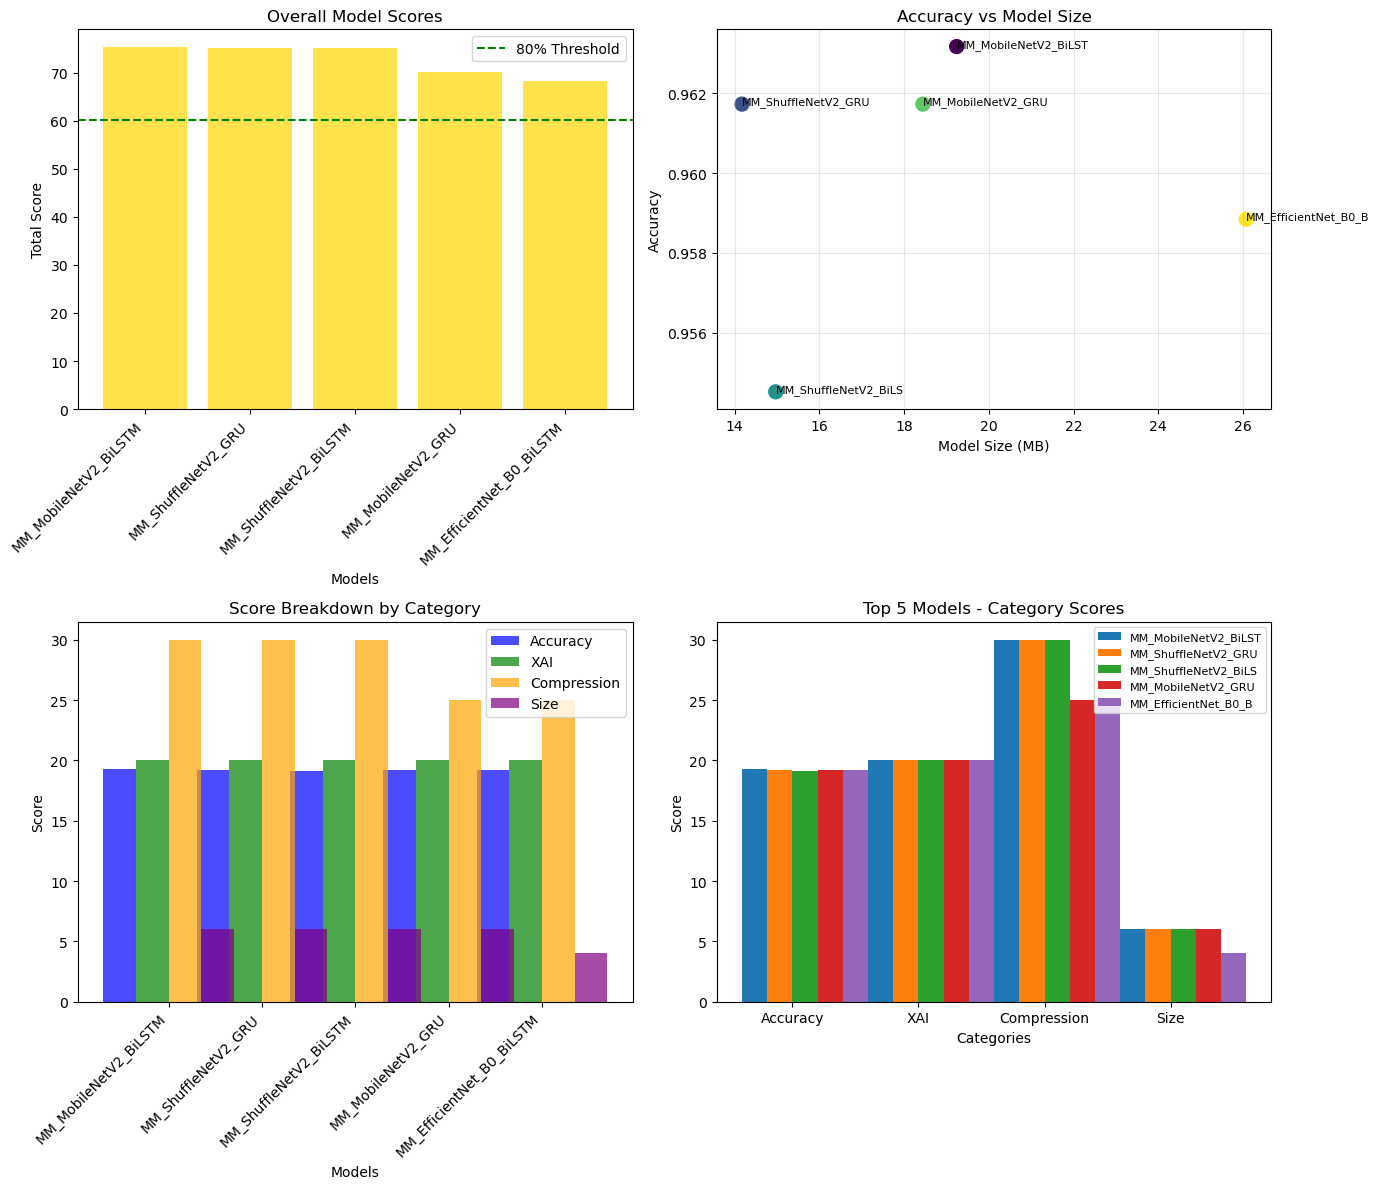

 Visualization saved to: Emotion_Models/benchmark_resultsmodel_selection_analysis.png
 MODEL SELECTION FOR DEPLOYMENT COMPLETE!


In [36]:
#  MODEL SELECTION FOR DEPLOYMENT

print(" MODEL SELECTION FOR DEPLOYMENT")
print("Evaluating models across XAI Quality and Compression Performance")


#  LOAD ALL COMPRESSION RESULTS

all_compression_results = []

# Load quantization results
if len(quantization_results) > 0:
    for r in quantization_results:
        r['technique_category'] = 'quantization'
        all_compression_results.append(r)

# Load pruning results
if len(pruning_results) > 0:
    for r in pruning_results:
        r['technique_category'] = 'pruning'
        all_compression_results.append(r)

# Load distillation results
if len(distillation_results) > 0:
    for r in distillation_results:
        r['technique_category'] = 'distillation'
        all_compression_results.append(r)

# Load XAI results
xai_models = {}
for model_name, data in xai_results.items():
    xai_models[model_name] = {
        'accuracy': data.get('accuracy', 0),
        'gradcam': data.get('gradcam', 'Failed'),
        'attention': data.get('attention', 'Failed'),
        'shap': data.get('shap', 'Failed')
    }


# CREATE COMPREHENSIVE SCORING

print("\n COMPREHENSIVE MODEL SCORING")

model_scores = {}

for model_name, data in loaded_models.items():
    print(f"\n Evaluating: {model_name}")
    
    # Get base model info
    base_acc = data['checkpoint']['best_accuracy']
    base_size = get_model_size_mb(data['model'])
    base_params = get_model_params(data['model']) / 1e6
    
    # Get XAI scores
    xai_score = 0
    xai_details = []
    
    if model_name in xai_models:
        xai_data = xai_models[model_name]
        
        # Grad-CAM: 0-10 points
        if 'Completed' in str(xai_data.get('gradcam', '')):
            xai_score += 10
            xai_details.append('Grad-CAM YES')
        elif 'Failed' in str(xai_data.get('gradcam', '')):
            xai_score += 2
            xai_details.append('Grad-CAM NO')
        else:
            xai_details.append('Grad-CAM NO')
        
        # Attention: 0-10 points
        if 'Completed' in str(xai_data.get('attention', '')):
            xai_score += 10
            xai_details.append('Attention YES')
        elif 'Failed' in str(xai_data.get('attention', '')):
            xai_score += 2
            xai_details.append('Attention NO')
        else:
            xai_details.append('Attention NO')
        
        # SHAP: 0-10 points
        shap_status = xai_data.get('shap', '')
        if 'Completed' in str(shap_status):
            xai_score += 10
            xai_details.append('SHAP YES')
        elif 'None' in str(shap_status) or 'Skipped' in str(shap_status):
            xai_score += 5
            xai_details.append('SHAP NO')
        else:
            xai_details.append('SHAP NO')
    
    # Get compression results for this model
    model_compression = [r for r in all_compression_results if r['model_name'] == model_name]
    
    compression_score = 0
    best_compression_ratio = 1
    best_technique = 'None'
    best_accuracy_loss = 0
    
    if model_compression:
        # Find best compression ratio
        for r in model_compression:
            ratio = r.get('compression_ratio', 1)
            loss = r.get('accuracy_loss', 1)
            
            # Score: high compression ratio + low accuracy loss
            if ratio > best_compression_ratio:
                best_compression_ratio = ratio
                best_technique = r.get('technique', 'unknown')
                best_accuracy_loss = loss
        
        # Calculate compression score (0-30 points)
        if best_compression_ratio > 1:
            # 10 points for compression ratio > 1.5x
            if best_compression_ratio >= 2.0:
                compression_score += 15
            elif best_compression_ratio >= 1.5:
                compression_score += 10
            elif best_compression_ratio >= 1.2:
                compression_score += 5
            
            # 10 points for low accuracy loss
            if best_accuracy_loss < 0.01:
                compression_score += 15
            elif best_accuracy_loss < 0.02:
                compression_score += 10
            elif best_accuracy_loss < 0.05:
                compression_score += 5
            
            # 5 points for having compression
            compression_score += 5
    
    # Accuracy score (0-20 points)
    accuracy_score = base_acc * 20
    
    # Size score (0-10 points)
    # Smaller models get higher score
    if base_size < 5:
        size_score = 10
    elif base_size < 10:
        size_score = 8
    elif base_size < 20:
        size_score = 6
    elif base_size < 30:
        size_score = 4
    elif base_size < 50:
        size_score = 2
    else:
        size_score = 0
    
    # Total score
    total_score = accuracy_score + xai_score + compression_score + size_score
    
    model_scores[model_name] = {
        'model_name': model_name,
        'accuracy': base_acc,
        'accuracy_score': accuracy_score,
        'size_mb': base_size,
        'size_score': size_score,
        'xai_score': xai_score,
        'xai_details': ' | '.join(xai_details),
        'compression_score': compression_score,
        'best_compression_ratio': best_compression_ratio,
        'best_technique': best_technique,
        'best_accuracy_loss': best_accuracy_loss,
        'total_score': total_score,
        'parameters_m': base_params
    }
    
    print(f"   Base Accuracy: {base_acc:.4f}")
    print(f"   Model Size: {base_size:.2f} MB")
    print(f"   XAI Score: {xai_score}/30 ({' | '.join(xai_details)})")
    print(f"   Compression Score: {compression_score}/30")
    print(f"   Best Compression: {best_technique} ({best_compression_ratio:.2f}x, loss={best_accuracy_loss:.4f})")
    print(f"   Total Score: {total_score:.1f}/70")

# RANK MODELS

print(" MODEL RANKING FOR DEPLOYMENT")

# Sort by total score
ranked_models = sorted(model_scores.values(), key=lambda x: x['total_score'], reverse=True)

print("\n Ranked Models (Best to Worst):")

print(f"{'Rank':<6} {'Model':<35} {'Score':<8} {'Accuracy':<10} {'Size':<10} {'XAI':<8} {'Compression':<12}")


for rank, model in enumerate(ranked_models, 1):
    print(f"{rank:<6} {model['model_name'][:35]:<35} {model['total_score']:<8.1f} {model['accuracy']:<10.4f} {model['size_mb']:<10.2f} {model['xai_score']:<8} {model['best_technique'][:12]:<12}")



#  BEST MODEL FOR EACH CATEGORY

print("\n BEST IN EACH CATEGORY:")

# Best Accuracy
best_acc = max(ranked_models, key=lambda x: x['accuracy'])
print(f"    Best Accuracy: {best_acc['model_name']} ({best_acc['accuracy']:.4f})")

# Best XAI
best_xai = max(ranked_models, key=lambda x: x['xai_score'])
print(f"    Best XAI: {best_xai['model_name']} ({best_xai['xai_score']}/30)")

# Best Compression
best_comp = max(ranked_models, key=lambda x: x['compression_score'])
print(f"    Best Compression: {best_comp['model_name']} ({best_comp['compression_score']}/30, {best_comp['best_compression_ratio']:.2f}x)")

# Best Size
best_size = min(ranked_models, key=lambda x: x['size_mb'])
print(f"    Smallest Model: {best_size['model_name']} ({best_size['size_mb']:.2f} MB)")


# RECOMMENDED MODEL FOR DEPLOYMENT


print(" RECOMMENDED MODEL FOR DEPLOYMENT")

best_overall = ranked_models[0]

print(f"\n BEST OVERALL MODEL: {best_overall['model_name']}")
print(f"   Accuracy: {best_overall['accuracy']:.4f}")
print(f"   Model Size: {best_overall['size_mb']:.2f} MB")
print(f"   Parameters: {best_overall['parameters_m']:.2f}M")
print(f"   XAI Score: {best_overall['xai_score']}/30")
print(f"   XAI Techniques: {best_overall['xai_details']}")
print(f"   Compression Score: {best_overall['compression_score']}/30")
print(f"   Best Compression Technique: {best_overall['best_technique']}")
print(f"   Best Compression Ratio: {best_overall['best_compression_ratio']:.2f}x")
print(f"   Total Score: {best_overall['total_score']:.1f}/70")


# SAVE SELECTION REPORT

print("\n Saving selection report...")

# Create report DataFrame
report_df = pd.DataFrame(ranked_models)
report_df.to_csv(os.path.join(BENCHMARK_DIR, 'model_selection_report.csv'), index=False)
print(f"    Report saved to: {BENCHMARK_DIR}model_selection_report.csv")

# Create deployment recommendation
deployment_recommendation = {
    'recommended_model': best_overall['model_name'],
    'accuracy': best_overall['accuracy'],
    'size_mb': best_overall['size_mb'],
    'xai_support': best_overall['xai_details'],
    'best_compression': best_overall['best_technique'],
    'compression_ratio': best_overall['best_compression_ratio'],
    'reason': 'Best balance of accuracy, interpretability, and compression potential'
}

with open(os.path.join(BENCHMARK_DIR, 'deployment_recommendation.json'), 'w') as f:
    import json
    json.dump(deployment_recommendation, f, indent=4)
print(f"    Deployment recommendation saved to: {BENCHMARK_DIR}deployment_recommendation.json")

# VISUALIZE RESULTS

print("\n Generating visualization...")

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Model Scores
models = [m['model_name'] for m in ranked_models]
scores = [m['total_score'] for m in ranked_models]
accuracies = [m['accuracy'] for m in ranked_models]
sizes = [m['size_mb'] for m in ranked_models]

x = np.arange(len(models))
width = 0.35

axes[0, 0].bar(x, scores, color='gold', alpha=0.7)
axes[0, 0].set_xlabel('Models')
axes[0, 0].set_ylabel('Total Score')
axes[0, 0].set_title('Overall Model Scores')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(models, rotation=45, ha='right')
axes[0, 0].axhline(y=scores[0]*0.8, color='green', linestyle='--', label='80% Threshold')
axes[0, 0].legend()

# 2. Accuracy vs Size
axes[0, 1].scatter(sizes, accuracies, s=100, c=range(len(models)), cmap='viridis')
for i, model in enumerate(models):
    axes[0, 1].annotate(model[:20], (sizes[i], accuracies[i]), fontsize=8)
axes[0, 1].set_xlabel('Model Size (MB)')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy vs Model Size')
axes[0, 1].grid(True, alpha=0.3)

# 3. Score Breakdown
xai_scores = [m['xai_score'] for m in ranked_models]
comp_scores = [m['compression_score'] for m in ranked_models]
acc_scores = [m['accuracy_score'] for m in ranked_models]
size_scores = [m['size_score'] for m in ranked_models]

axes[1, 0].bar(x - width*1.5, acc_scores, width, label='Accuracy', color='blue', alpha=0.7)
axes[1, 0].bar(x - width*0.5, xai_scores, width, label='XAI', color='green', alpha=0.7)
axes[1, 0].bar(x + width*0.5, comp_scores, width, label='Compression', color='orange', alpha=0.7)
axes[1, 0].bar(x + width*1.5, size_scores, width, label='Size', color='purple', alpha=0.7)
axes[1, 0].set_xlabel('Models')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Score Breakdown by Category')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(models, rotation=45, ha='right')
axes[1, 0].legend()

# 4. Top 5 Models Radar Chart
top5 = ranked_models[:5]
categories = ['Accuracy', 'XAI', 'Compression', 'Size']
values = []
for model in top5:
    values.append([
        model['accuracy'] * 20,  # Normalize to 0-20
        model['xai_score'],
        model['compression_score'],
        model['size_score']
    ])

# Simple bar chart for top 5
ax = axes[1, 1]
for i, (model, vals) in enumerate(zip(top5, values)):
    x_pos = np.arange(len(categories)) + i * 0.2
    ax.bar(x_pos, vals, width=0.2, label=model['model_name'][:20])
ax.set_xlabel('Categories')
ax.set_ylabel('Score')
ax.set_title('Top 5 Models - Category Scores')
ax.set_xticks(np.arange(len(categories)) + 0.3)
ax.set_xticklabels(categories)
ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(BENCHMARK_DIR, 'model_selection_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f" Visualization saved to: {BENCHMARK_DIR}model_selection_analysis.png")


print(" MODEL SELECTION FOR DEPLOYMENT COMPLETE!")